In [1]:
# pip install jenkspy

In [45]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import math
import statsmodels.api as sm

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import jenkspy

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
# from scipy.cluster.hierarchy import dendrogram


pd.set_option('display.max_columns', None)

## Loading and Overview

In [3]:
# ____________________________________________________________________________________________________________
# Loading the previously validated dataset. See more in data_load folder of the repository
# ____________________________________________________________________________________________________________

data_ldn = pd.read_csv(
    "data_load/final_output.csv", na_values=["NULL", "null", "None", "", "[]", "NaN"])
data_ldn_exstg = data_ldn[data_ldn["completed"] == "Completed"].drop(axis=1, columns=['completed']) #taking only the data centres that were built
# data_ldn_exstg = data_ldn
data_ldn_exstg = data_ldn_exstg.sort_values(by="data_centre_since", ascending=True)
data_ldn_exstg.head(1)

# ____________________________________________________________________________________________________________
# Creating a set of new columns
# ____________________________________________________________________________________________________________
data_ldn_exstg["b8_gia_sqm_per_ha"] = data_ldn_exstg["b8_gia_sqm"] / data_ldn_exstg["application_details_site_area"] 
data_ldn_exstg["b8_gia_ha_per_site_ha"] = (data_ldn_exstg["b8_gia_sqm"] /10000) / data_ldn_exstg["application_details_site_area"]
data_ldn_exstg["b8_gia_1000_sqm"] = data_ldn_exstg["b8_gia_sqm"] / 1000
data_ldn_exstg["b8_total_staff_per_1000_sqm"] = data_ldn_exstg["b8_total_staff_fte"] / data_ldn_exstg["b8_gia_1000_sqm"]

#scaling years column to keep condition n at bay
col = "data_centre_since"

min_year = data_ldn_exstg[col].min()
max_year = data_ldn_exstg[col].max()
year_range = max_year - min_year
data_ldn_exstg["data_centre_since_scaled"] = ((data_ldn_exstg[col] - min_year) + 1)

The dataset includes built data centres of various sizes. Those under construction are excluded as we can't verify their real employment before operational stage.

In [4]:
data_ldn_exstg.describe()

,application_details_site_area,data_centre_since,b8_no_storeys,b8_max_height_m,b8_gia_sqm,b8_total_staff_fte,utility_total_electr_capacity_mva,it_load_capacity_mw,density_kw_max_per_sqm,pue,tier,security_staff,cleaners_staff,managers_staff,site_engineers_staff,visitor_staff_not_on_site,cluster_staff_not_on_site,b8_employees_at_a_day_reported,total/day ratio,b8_employees_at_a_day_estimate,b8_gia_sqm_per_ha,b8_gia_ha_per_site_ha,b8_gia_1000_sqm,b8_total_staff_per_1000_sqm,data_centre_since_scaled
count,39.000000,47.000000,39.000000,29.000000,45.000000,26.000000,15.000000,25.00000,25.000000,12.000000,17.0,5.000000,3.000000,4.000000,4.000000,6.000000,1.0,11.000000,4.000000,11.000000,37.000000,37.000000,45.000000,26.000000,47.000000
mean,1.271336,2009.404255,3.948718,614.349069,12721.678551,76.384615,28.613333,15.36200,1.809200,1.342417,3.0,9.800000,4.333333,9.750000,25.250000,10.500000,13.0,25.636364,2.990000,25.636364,22930.011524,2.293001,12.721679,13.442565,31.404255
std,1.435416,9.023302,3.244012,3209.145950,14731.554698,79.227812,23.328856,16.30319,0.705962,0.314106,0.0,4.024922,2.886751,13.524669,27.801379,14.570518,NaN,18.704399,1.134578,18.704399,30880.138037,3.088014,14.731555,25.945742,9.023302
min,0.009000,1979.000000,1.000000,4.400000,24.000000,5.000000,2.000000,1.35000,0.920000,0.700000,3.0,5.000000,1.000000,2.000000,7.000000,1.000000,13.0,7.000000,1.970000,7.000000,155.844156,0.015584,0.024000,0.560224,1.000000
25%,0.205500,2002.000000,2.000000,10.000000,2400.000000,17.750000,9.850000,4.00000,1.250000,1.287500,3.0,6.000000,3.500000,2.750000,7.750000,5.000000,13.0,17.500000,2.307500,17.500000,6123.499142,0.612350,2.400000,2.707760,24.000000
50%,1.000000,2011.000000,2.000000,12.500000,7150.000000,45.000000,24.000000,10.00000,1.720000,1.300000,3.0,12.000000,6.000000,3.500000,14.000000,5.500000,13.0,20.000000,2.710000,20.000000,12486.848485,1.248685,7.150000,4.142176,33.000000
75%,1.980000,2017.000000,5.500000,24.350000,18116.000000,97.500000,44.500000,21.00000,2.400000,1.327250,3.0,12.000000,6.000000,10.500000,31.500000,6.000000,13.0,25.500000,3.392500,25.500000,25910.364146,2.591036,18.116000,15.721416,39.000000
max,7.540000,2025.000000,13.000000,17300.000000,69829.000000,262.000000,80.000000,64.00000,3.500000,2.100000,3.0,14.000000,6.000000,30.000000,66.000000,40.000000,13.0,62.000000,4.570000,62.000000,136800.000000,13.680000,69.829000,128.645782,47.000000


> **Status and ownership**
> -  Unique PA reference - **id**
> -  DC postcode - **postcode**
> -  DC address - **address**
> -  Category col indicating the state of completion - **completed**
> -  Date when DC was operational for the first time in this building. Note the size and staff numbers reflect the current situation, not when DC opened - **data_centre_since**
> -  Year/date when the first pre-app stage document was received - **preapp_started**
> -  Boolean col indicating whether DC is enterprise or any other type - **enterprise**
> -  Current owner/occupier of DC - **current_occupier**
> -  Company website - **website**
> -  Unique property reference - **uprn**
> -  Local authority (borough) name - **lpa_name**. Note a few of DC in Slough were manually added as the information became available. Slough DC will only be used for size and staff analysis, not for the spatial clustering

> **Attached planning application**
> -  PA code (contains repetitions with unique other columns, use id for cross-comparing) - **lpa_app_no**
> -  PA webpage - **url_planning_app**
> -  PA decision date - **decision_date**. Note it does not always represent a moment when the DC was created 
> -  PA description. Note it sometimes refers to PAs with additions to DC, not its development - **description**
> -  Notes about the application and current use - **notes**
> -  PA system update - **last_updated**
> -  Helper column with the data source – **is_full_planning**

> **Spatial parameters**
> -  Gross internal area of the DC use - **b8_gia_sqm**
> -  Site area in hectares – **application_details_site_area**
> -  Number of storeys in the DC building, or stories occupied by the DC if other uses present - **b8_no_storeys**
> -  Height of the DC in meters **b8_max_height_m**
> -  List of other uses within the building with the DC – **other_use_classes_present_within_b8_building**
> -  Geometry cols - **geometry_point, geometry**

> **Employment data**
> -  Total staff number in the DC - **b8_total_staff_fte**
> -  N of security staff - **security_staff**
> -  N of engineering/technical staff - **site_engineers_staff**
> -  N of administrative staff - **managers_staff**
> -  N of cleaning/housekeeping staff - **cleaners_staff**
> -  N of visitor staff, typically client technicians - **visitor_staff_not_on_site**
> -  N of staff working within one cluster, if more than one DC is in the area. Mostly refers to admin/technicians - **cluster_staff_not_on_site**
> -  N of staff present on site per day - **b8_employees_at_a_day**

In [5]:
# ____________________________________________________
# Helper function
# ____________________________________________________

def make_transparent(color, alpha=0.3):
    if color.startswith("rgb"):
        return color.replace(")", f", {alpha})").replace("rgb", "rgba")
    elif color.startswith("#"):
        r, g, b = tuple(int(color[i:i+2], 16) for i in (1, 3, 5))
        return f"rgba({r},{g},{b},{alpha})"
    return color

notes_colour = "black"
labels_colour = "grey"

In [7]:
missing_pct = (data_ldn_exstg.isnull().mean() * 100).sort_values(ascending=False)
fig = px.bar(missing_pct,labels={"value": "% missing", "index": "Column name"}, color_discrete_sequence=[px.colors.qualitative.Plotly[1]])
fig.update_layout(width=1000, height=400, template="plotly_white", showlegend=False,
    title=dict(
            text=(
                f"<span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
                "Missing values by column (%)"
                "</span><br>"
            ),
            x=0.03,xanchor="left",y=0.92,yanchor="top",
        ),
        margin=dict(t=90),legend=dict(font=dict(color=labels_colour)),
    )

fig.update_xaxes(title_font=dict(color=labels_colour),tickfont=dict(color=labels_colour))
fig.update_yaxes(title_font=dict(color=labels_colour),tickfont=dict(color=labels_colour))
fig.show()

# ____________________________________________________________________________________________________________
# The dataset has a lot of NA values, and it will present an obstacle for clustering.
# My solution is to follow a stepwise approach to this study, and fill the NA where appropriate, once the basis for this is determined.
# ____________________________________________________________________________________________________________

## Clustering

Recent research by the House Of Commons outlines four DC types: 

- enterprise (operated by an organisation for internal purposes), 
- co-location (third party renting rack space to customers), 
- hyperscale (large facilities by major cloud providers), 
- AI (designed for high-performance computing).

The dataset contains several variables that could inform clustering of DC, e.g. b8_gia_sqm, it_load_capacity_mw (both numeric). **To identify distinct data centre groups, k-means clustering is applied using these 3 numeric cols. The assumption of the k=4 is validated through the elbow method.**
<!-- 
Apart from operational, security and other differences, they can vary by GIA. Below we perform the segmentation using Jenks natural breaks. This method is appropriate for small, 1-dimentional data (GIA) with potentially unequal number of datapoints in each class, and skewed distributions (see chart below). The method optimizes for total intra-class variance, making the classes as homogeneous as possible. (hhttps://observablehq.com/@visionscarto/natural-breaks). -->

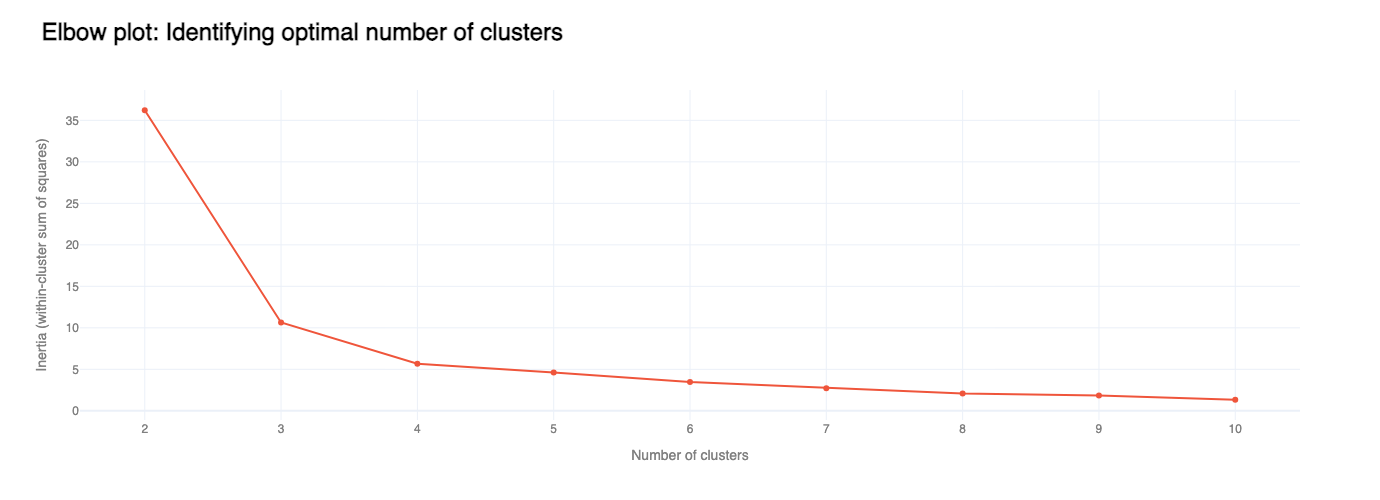

In [103]:
data_sizes_no_na = data_ldn_exstg[["b8_gia_sqm", "it_load_capacity_mw"]]
data_sizes_no_na = data_sizes_no_na.dropna(subset=["b8_gia_sqm"])

# Use K-nearest neighbours imputation (k = 5)
# I am filling MW and KW columns, but not the GIA since it is most filled and most reliable. Also, for most null GIA, the other columns are null as well
imputer = KNNImputer(n_neighbors=5)
data_sizes_imputed_array = imputer.fit_transform(data_sizes_no_na)
data_sizes_no_na = pd.DataFrame(data_sizes_imputed_array,columns=["b8_gia_sqm", "it_load_capacity_mw"],index=data_sizes_no_na.index)

scaler = StandardScaler()
scaled_array = scaler.fit_transform(data_sizes_no_na)
data_sizes_no_na = pd.DataFrame(scaled_array,columns=["b8_gia_sqm", "it_load_capacity_mw"],index=data_sizes_no_na.index)
# ___________________________________________________________________________________________________________
# elbow plot
#____________________________________________________________________________________________________________

X = data_sizes_no_na[["b8_gia_sqm", "it_load_capacity_mw"]]
inertias = []
k_values = list(range(2, 11))

for k in k_values:
    kmeans = KMeans(n_clusters=k,random_state=42,n_init="auto")
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

fig = go.Figure()
fig.add_trace(go.Scatter(x=k_values,y=inertias,mode="lines+markers",name="Inertia", line=dict(color=px.colors.qualitative.Plotly[1]), marker=dict(color=px.colors.qualitative.Plotly[1])))
fig.update_layout(
    width=1000,height=500, template="plotly_white",
    title=dict(
        text=(
            f"<span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
            "Elbow plot: Identifying optimal number of clusters"
            "</span><br>"
        ),
        x=0.03,xanchor="left", y=0.92,yanchor="top",
    ),
    margin=dict(t=90), legend=dict(font=dict(color=labels_colour)),
    xaxis_title="Number of clusters",yaxis_title="Inertia (within-cluster sum of squares)",
)

fig.update_xaxes(title_font=dict(color=labels_colour),tickfont=dict(color=labels_colour))
fig.update_yaxes(title_font=dict(color=labels_colour),tickfont=dict(color=labels_colour))
fig.show()

In [106]:
k_means_optimum = KMeans(n_clusters = 3, init = 'k-means++', random_state=42, n_init="auto")
y = k_means_optimum.fit_predict(X)
# print(y)

# write clusters into the initial dataframe
data_ldn_exstg["cluster"] = np.nan
data_ldn_exstg.loc[data_sizes_no_na.index, "cluster"] = y

score = silhouette_score(X,y)
print(score)

0.653128045657962


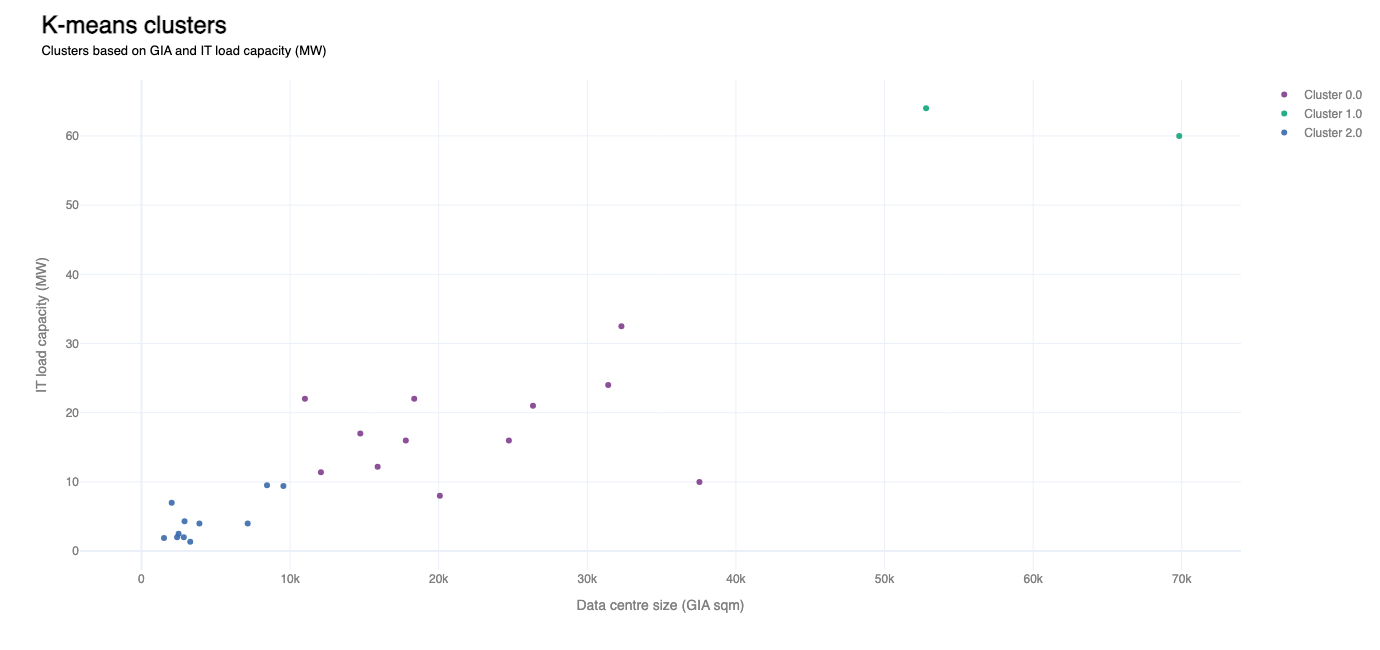

In [107]:
# https://medium.com/@sk.shravan00/k-means-for-3-variables-260d20849730
# data_sizes_no_na["cluster"] = y
palette = px.colors.qualitative.Bold
df_plot = data_ldn_exstg
xcol = "b8_gia_sqm"
ycol = "it_load_capacity_mw"
clusters_sorted = sorted(df_plot["cluster"].unique())
cols_to_show = ["id","current_occupier","lpa_name","data_centre_since","b8_gia_sqm","b8_total_staff_fte", xcol, ycol, zcol]
hovertemplate = "<br>".join([f"{c}: %{{customdata[{i}]}}" for i, c in enumerate(cols_to_show)])

fig = go.Figure()

for i, cl in enumerate(clusters_sorted):
    d = df_plot[df_plot["cluster"] == cl]
    fig.add_trace(go.Scatter(x=d[xcol], y=d[ycol],
        mode="markers",marker=dict(size=6,color=palette[i % len(palette)],opacity=0.9,), name=f"Cluster {cl}",
        customdata=d[cols_to_show].to_numpy(), hovertemplate=hovertemplate,
    )) 
fig.update_layout(
    width=800, height=650, template="plotly_white",
    title=dict(
        text=(
            f"<span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block;'>"
            "K-means clusters"
            "</span><br>"
            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block;'>"
            "Clusters based on GIA and IT load capacity (MW)"
            "</span>"
        ),
        x=0.03,xanchor="left",y=0.95,yanchor="top"
    ),
    margin=dict(t=80),legend=dict(font=dict(color=labels_colour)),
)
fig.update_xaxes(title_text="Data centre size (GIA sqm)",title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))
fig.update_yaxes(title_text="IT load capacity (MW)", title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))
fig.show()

We have identified 3 clusters:

- Small with low load capacity
- Medium-low size and capacity
- Large with high load capacity (smallest group, potentially due to their location just outside London boundary - they are not included into the sample)

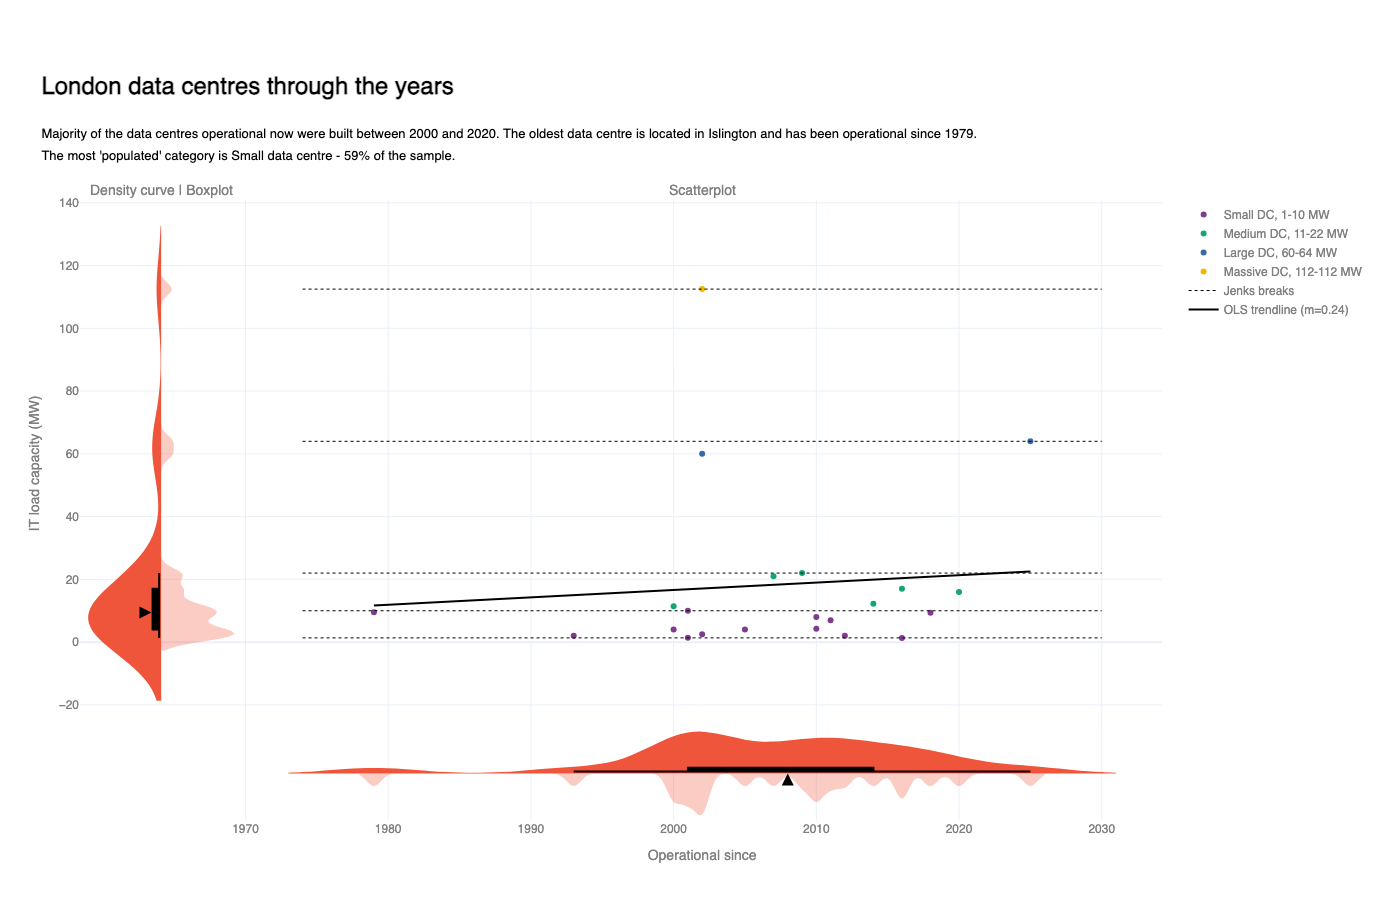

In [21]:
#______________________________________
# Build subplots
#______________________________________
notes_colour, labels_colour = "black", "grey"
df = data_ldn_exstg.dropna(subset=["it_load_capacity_mw", "data_centre_since"]).copy()

cols_to_show = ["id","current_occupier","lpa_name","data_centre_since","b8_gia_sqm",
                "b8_total_staff_fte","b8_employees_at_a_day_estimate","total/day ratio"]

hovertemplate = "<br>".join([f"{c}: %{{customdata[{i}]}}" for i, c in enumerate(cols_to_show)])
base_color, colors = px.colors.qualitative.Plotly[1], px.colors.qualitative.Bold
main_x, main_y = df["data_centre_since"], df["it_load_capacity_mw"]
median_value, median_year = main_y.median(), main_x.median()

fig = make_subplots(
    rows=2, cols=2, shared_yaxes=True, shared_xaxes=True,
    column_widths=[0.15, 0.85], row_heights=[0.85, 0.15],
    horizontal_spacing=0.0, vertical_spacing=0.0,
    subplot_titles=["Density curve | Boxplot", "Scatterplot", None, None],
    specs=[[{"type":"xy"},{"type":"xy"}],[{"type":"xy"},{"type":"xy"}]],
)
fig.update_annotations(font=dict(size=14, color=labels_colour))
#______________________________________
# Scatterplot
#______________________________________
for i, band in enumerate(gia_labels):
    d = df[df["it_load_capacity_mw_group"] == band]
    if d.empty: 
        continue
    fig.add_trace(go.Scatter(
        x=d["data_centre_since"], y=d["it_load_capacity_mw"], mode="markers",marker=dict(size=6, color=colors[i % len(colors)]),
        customdata=d[cols_to_show].to_numpy(), hovertemplate=hovertemplate,name=f"{band} DC, {int(d['it_load_capacity_mw'].min()):,}-{int(d['it_load_capacity_mw'].max()):,} MW",
    ), row=1, col=2)

# Breaks
for i, b in enumerate(breaks):
    fig.add_trace(go.Scatter(
        x=[main_x.min()-5, main_x.max()+5], y=[b, b], mode="lines",line=dict(color="black", width=1, dash="dot"), name="Jenks breaks" if i == 0 else None,
        showlegend=(i == 0), hovertemplate=f"Jenks break<br>IT load boundary: {b:.2f} MW<br><extra></extra>", hoverinfo="text"
    ), row=1, col=2)
#______________________________________
# Density curves (LEFT - vertical violin for main_y)
#______________________________________
fig.add_trace(go.Violin(y=main_y, x0=1, orientation="v", side="positive", points=False,
                        bandwidth=2, width=45, line=dict(width=0),fillcolor=make_transparent(base_color, 0.3),
                        showlegend=False, hoverinfo="skip"), row=1, col=1)

fig.add_trace(go.Violin(y=main_y, orientation="v", side="negative", points=False,width=45, bandwidth=10, line=dict(width=0),
                        box_visible=True, box_fillcolor="black",box_line=dict(color="black", width=2), box_width=0.18, fillcolor=base_color, showlegend=False, hoverinfo="skip"), row=1, col=1)

fig.add_scatter(x=[-2], y=[median_value], mode="markers",
                marker=dict(symbol="arrow-right", color="black", size=12), showlegend=False, hoverinfo="skip")
#______________________________________
# Density curve (BOTTOM - horizontal violin for main_x)
#______________________________________
fig.add_trace(go.Violin(x=main_x, y0=0, orientation="h", side="negative", points=False,
                        bandwidth=0.5, width=0.8, line=dict(width=0),
                        fillcolor=make_transparent(base_color, 0.3),
                        showlegend=False, hoverinfo="skip"), row=2, col=2)

fig.add_trace(go.Violin(x=main_x, y0=0, orientation="h", side="positive", points=False,
                        width=0.8, bandwidth=3, line=dict(width=0),
                        box_visible=True, box_fillcolor="black",
                        box_line=dict(color="black", width=2), box_width=0.18,
                        fillcolor=base_color, showlegend=False, hoverinfo="skip"), row=2, col=2)

fig.add_trace(go.Scatter(x=[median_year], y=[0], mode="markers",
                        marker=dict(symbol="arrow-up", color="black", size=12),
                        showlegend=False, hoverinfo="skip"), row=2, col=2)
#______________________________________
# Trendline
#______________________________________
x, y = main_x.to_numpy(), main_y.to_numpy()
m, c = np.polyfit(x, y, 1)
xt = np.linspace(main_x.min(), main_x.max(), 100)
fig.add_trace(go.Scatter(x=xt, y=m*xt + c, mode="lines",
                         line=dict(color="black", width=2),
                         name=f"OLS trendline (m={m:.2f})"), row=1, col=2)
#______________________________________
# Layout updates - adding title and subtitle notes
#______________________________________
fig.update_layout(
    width=1000, height=900, template="plotly_white",
    title=dict(
        text=(
            f"<br><span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
            "London data centres through the years"
            "</span><br><br>"
            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:0px;'>"
            "Majority of the data centres operational now were built between 2000 and 2020. "
            f"The oldest data centre is located in {df.loc[main_x.idxmin(), 'lpa_name']} and has been operational since {int(main_x.min())}. "
            "</span><br>"
            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:0px;'>"
            # "Data centre GIA is broadly stable over time; unbuilt pipeline sites are excluded. "
            f"The most 'populated' category is {df['it_load_capacity_mw_group'].value_counts().idxmax()} data centre - {(df['it_load_capacity_mw_group'].value_counts().max() / (df['it_load_capacity_mw_group'].notna().sum() / 100)):,.0f}% of the sample." 
            "</span><br>"
        ),
        x=0.03, xanchor="left", y=0.92, yanchor="top",
    ),
    margin=dict(t=200),
    legend=dict(font=dict(color=labels_colour))
)

# Axis labels (scatter axes)
fig.update_xaxes(title_text="Operational since", row=2, col=2,
                 title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))
fig.update_yaxes(title_text="IT load capacity (MW)", row=1, col=1,
                 title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))

# hide axis clutter on distribution panels
fig.update_xaxes(showticklabels=False, row=1, col=1)
fig.update_yaxes(showticklabels=False, row=2, col=2)

# hide the empty bottom-left subplot completely
fig.update_xaxes(visible=False, row=2, col=1)
fig.update_yaxes(visible=False, row=2, col=1)

fig.show()

In [12]:
# #______________________________________
# # Build subplots
# #______________________________________

# notes_colour = "black"
# labels_colour = "grey"

# df = data_ldn_exstg.dropna(subset=["b8_gia_sqm", "data_centre_since"]).copy()
# # df = df.sort_values(by="data_centre_since", ascending=True)

# cols_to_show = ["id", "current_occupier", "lpa_name", "data_centre_since", "b8_gia_sqm", "b8_total_staff_fte", "b8_employees_at_a_day_estimate", "total/day ratio"]
# customdata = df[cols_to_show].to_numpy()
# hovertemplate = "<br>".join([f"{col}: %{{customdata[{i}]}}" for i, col in enumerate(cols_to_show)])
# base_color = px.colors.qualitative.Plotly[1]
# # base_color = "grey"
# colors = px.colors.qualitative.Bold

# main_x = df["data_centre_since"]
# main_y = df["b8_gia_sqm"]

# median_value = main_y.median()

# fig = make_subplots(
#     rows=1,
#     cols=2,
#     shared_yaxes=True,
#     column_widths=[0.15, 0.85],
#     horizontal_spacing=0.00,
#     subplot_titles=["Density curve | Boxplot", "Scatterplot"],
# )
# fig.update_annotations(
#     font=dict(
#         size=14,
#         color=labels_colour     
#     )
# )

# #______________________________________
# # Scatterplot
# #______________________________________
# bands_sorted = sorted(df["B8_gia_group"].dropna().unique())

# for i, band in enumerate(gia_labels):
#     df_band = df[df["B8_gia_group"] == band]

#     fig.add_trace(go.Scatter(
#         x=df_band["data_centre_since"],
#         y=df_band["b8_gia_sqm"],
#         mode="markers",
#         marker=dict(
#             size=8,
#             color=colors[i % len(colors)],
#         ),
#         customdata=df_band[cols_to_show].to_numpy(),
#         hovertemplate=hovertemplate,
#         name=f"{band} data centre, {int(df.loc[df["B8_gia_group"] == band, "b8_gia_sqm"].min()):,}-{int(df.loc[df["B8_gia_group"] == band, "b8_gia_sqm"].max()):,} sqm",
#         # name=f"{band} data centre, {df.loc[df["B8_gia_group"] == band, "b8_gia_sqm"].min()}-{df.loc[df["B8_gia_group"] == band, "b8_gia_sqm"].max()} sqm",
#     ), row=1, col=2)

# # Breaks
# for i, b in enumerate(breaks):
#     fig.add_trace(go.Scatter(
#         x=[main_x.min(), main_x.max()],   # span YEARS
#         y=[b, b],                         # horizontal line at GIA break
#         mode="lines",
#         line=dict(color="black", width=1, dash="dot"),
#         name="Jenks natural breaks" if i == 0 else None,
#         showlegend=True if i == 0 else False,
#         hovertemplate=(
#             f"Jenks break<br>"
#             f"GIA break: {b:,.0f} sqm<br>"
#             "<extra></extra>"
#         ),
#         hoverinfo="text"
#     ), row=1, col=2)

# #______________________________________
# # Density curves
# #______________________________________

# # bottom
# fig.add_trace(go.Violin(
#     y=main_y,
#     x0=1,
#     orientation="v", 
#     side="positive", 
#     points=False, 
#     bandwidth=600, 
#     width=45, 
#     line=dict(width=0), 
#     fillcolor=make_transparent(base_color, alpha=0.3), 
#     showlegend=False, 
#     hoverinfo="skip" 
# ), row=1, col=1)

# # top
# fig.add_trace(go.Violin(
#     y=main_y,
#     orientation="v",
#     side="negative",
#     width=45,
#     bandwidth=6000,
#     line=dict(width=0),
#     points=False,
#     box_visible=True,
#     box_fillcolor="black",
#     box_line=dict(color="black", width=2),
#     box_width=0.12,
#     fillcolor=base_color,
#     showlegend=False,
#     hoverinfo="skip",
# ), row=1, col=1)

# # median
# fig.add_scatter(
#     x=[0],
#     y=[median_value],
#     mode='markers',
#     marker=dict(symbol='arrow-right', color='black', size=12),
#     showlegend=False,
#     hoverinfo="skip"
# )

# #______________________________________
# # Trendline
# #______________________________________

# # OLS fit (y = m*x + c)
# x = main_x.to_numpy()
# y = main_y.to_numpy()
# m, c = np.polyfit(x, y, 1)

# # Trendline values
# x_trend = np.linspace(main_x.min(), main_x.max(), 100)
# y_trend = m * x_trend + c

# # OLS trendline
# fig.add_trace(go.Scatter(
#     x=x_trend,
#     y=y_trend,
#     mode="lines",
#     line=dict(color="black", width=2),
#     name=f"OLS trendline. Slope: {m:.2f}, intercept: {c:,.0f} sqm."
# ), row=1, col=2)

# #______________________________________
# # Layout updates - adding title and subtitle notes
# #______________________________________
# fig.update_layout(
#     width=1000,
#     height=600,
#     template="plotly_white",
#     # paper_bgcolor="#f9f4ed",
#     # plot_bgcolor="#f9f4ed",
#     title=dict(
#        text=(
#             f"<br><span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
#             "London data centres through the years"
#             "</span><br><br>"
        
#             f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:0px;'>"
#             "Majority of the data centres operational now were built between 2000 and 2020. "
#             f"The oldest data centre is located in {df.loc[main_x.idxmin(), 'lpa_name']} and has been operational since {int(main_x.min())}. "
#             "</span><br>"

#             f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:0px;'>"
#             "Data centre GIA is broadly stable over time; unbuilt pipeline sites are excluded. "
#             "</span><br>"
           
#             f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block;margin-bottom:0px;'>"
#             f"The most 'populated' category is {df["B8_gia_group"].value_counts().idxmax()} data centre (between {int(df.loc[df["B8_gia_group"] == "Small", "b8_gia_sqm"].min())} and {int(df.loc[df["B8_gia_group"] == "Small", "b8_gia_sqm"].max())}sqm GIA) - {(df["B8_gia_group"].value_counts().max() / (len(df["B8_gia_group"].notna()) / 100)):,.0f}% of the sample."
#             "</span><br>"

#         ),

#         x=0.03,
#         xanchor="left",
#         y=0.92,
#         yanchor="top",
#     ),
#     margin=dict(t=200),
#     legend=dict(
#         font=dict(color=labels_colour)
#     )
# )

# # Axis labels
# fig.update_xaxes(
#     title_text="Operational since",
#     row=1, col=2,
#     title_font=dict(color=labels_colour),
#     tickfont=dict(color=labels_colour)
# )

# fig.update_yaxes(
#     title_text="Gross Internal Area, sqm",
#     row=1, col=1,
#     title_font=dict(color=labels_colour),
#     tickfont=dict(color=labels_colour)
# )

# fig.update_yaxes(showticklabels=False, row=1, col=2)
# fig.update_xaxes(showticklabels=False, row=1, col=1)


# fig.show()

## Imputation 

With these groups in mind, we can approach imputation of the employment data. 

The staff column with most non-null values is **b8_total_staff_fte** - most applications just provide the total staff numbers in Full-Time Equivalent. Using a subset of those rows with **b8_employees_at_a_day**, we estimate the mean ratio of total-to-daily staff numbers for each DC group, and fill the null values.

In [13]:
# #________________________________________________________________________________________________________________________________________________
# # b8_total_staff_fte –> b8_employees_at_a_day_estimate
# # NOTE we also have null values in the b8_total_staff_fte column, but the dataset is too small to apply 
# # ML techniques to predict total staff N from other columns, which can also be null.
# # In the future, if there will be a larger dataset, this could be done.
# #________________________________________________________________________________________________________________________________________________
# B8_gia_group_mean = data_ldn_exstg.groupby("B8_gia_group", observed=True)["total/day ratio"].transform("mean")
# # B8_gia_overall_mean = data_ldn_exstg["total/day ratio"].mean()  # fallback if group mean is NaN #i will not impute overall means

# data_ldn_exstg["total/day ratio"] = (
#     data_ldn_exstg["total/day ratio"]
#     .fillna(B8_gia_group_mean)
#     # .fillna(B8_gia_overall_mean) #i will not impute overall means
# )

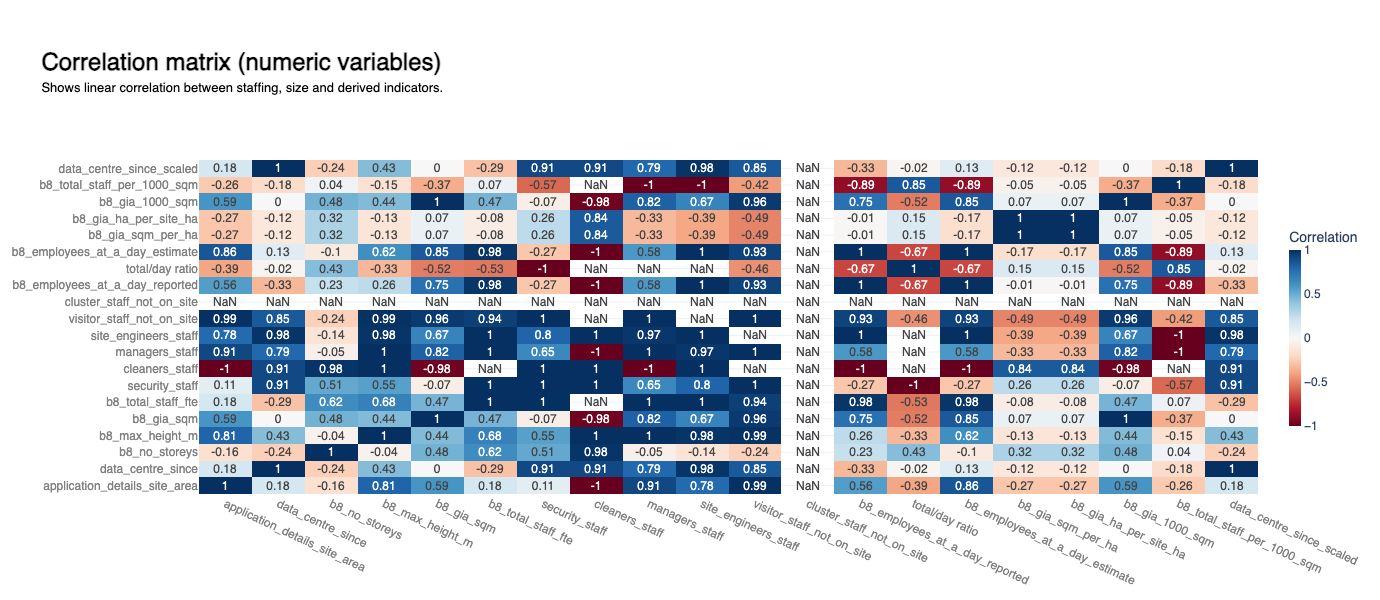

In [14]:
#________________________________________________________________________________________________________________________________________________
# Correlation matrix
#________________________________________________________________________________________________________________________________________________
corr_cols = data_ldn_exstg.select_dtypes(include="number").columns.to_list()

df = data_ldn_exstg[corr_cols].copy()
corr = df.corr(numeric_only=True)

fig = go.Figure(go.Heatmap(z=corr.values,x=corr.columns,y=corr.index,
    colorscale="RdBu",zmin=-1,zmax=1,
    text=corr.round(2).values,texttemplate="%{text}",
    hovertemplate="X: %{x}<br>Y: %{y}<br>Correlation: %{z:.2f}<extra></extra>",
    colorbar=dict(
        title="Correlation",len=0.65, thickness=12,x=1.02,
        # tickfont=dict(color=labels_colour),titlefont=dict(color=labels_colour),
    ),
))

fig.update_layout(
    width=1000,height=600,template="plotly_white",
    title=dict(
        text=(
            f"<br><span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
            "Correlation matrix (numeric variables)"
            "</span><br>"
            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:0px;'>"
            "Shows linear correlation between staffing, size and derived indicators."
            "</span><br>"
        ),
        x=0.03,xanchor="left",
        y=0.92,yanchor="top",
    ),
    margin=dict(t=160),
)

fig.update_xaxes(tickangle=25, tickfont=dict(color=labels_colour), title_font=dict(color=labels_colour))
fig.update_yaxes(tickfont=dict(color=labels_colour), title_font=dict(color=labels_colour))
fig.show()

The theme is not researched, and it is not possible to use desktop study to identify suitable variables to try explain the staff numbers. Also, the dataset doesn't contain an important piece of data for DC research - megawatt usage/capacity. In the future, it could be added into the variable list.
We now test several variables together to determine the relationship to **b8_total_staff_fte**, specifically those that will not create multicollinearity issues, and have less null values in the dataset. Candidates:

- **data_centre_since** The operation start date could affect data centre types, that are not captured by grouping based on the GIA alone;
- **b8_gia_sqm** Basic assumption is that the larger the facility is, the more staff it requires;
- **application_details_site_area** Alternative measure for DC size. Correlated with N of cleaners, managers, engineers, but not the security. Will cause multicollinearity with GIA, and is added to have more choice of variables if GIA has low beta-coefficients.

In [15]:
data_ldn_exstg.columns

Index(['lpa_name', 'uprn', 'decision_date', 'id', 'postcode', 'description',
       'last_updated', 'lpa_app_no', 'url_planning_app',
       'application_details_site_area', 'is_full_planning', 'geometry_point',
       'geometry', 'notes', 'enterprise', 'current_occupier', 'website',
       'address', 'data_centre_since', 'preapp_started', 'b8_no_storeys',
       'b8_max_height_m', 'b8_gia_sqm',
       'other_use_classes_present_within_b8_building', 'b8_total_staff_fte',
       'security_staff', 'cleaners_staff', 'managers_staff',
       'site_engineers_staff', 'visitor_staff_not_on_site',
       'cluster_staff_not_on_site', 'b8_employees_at_a_day_reported',
       'total/day ratio', 'b8_employees_at_a_day_estimate',
       'b8_gia_sqm_per_ha', 'b8_gia_ha_per_site_ha', 'b8_gia_1000_sqm',
       'b8_total_staff_per_1000_sqm', 'data_centre_since_scaled',
       'B8_gia_group'],
      dtype='object')

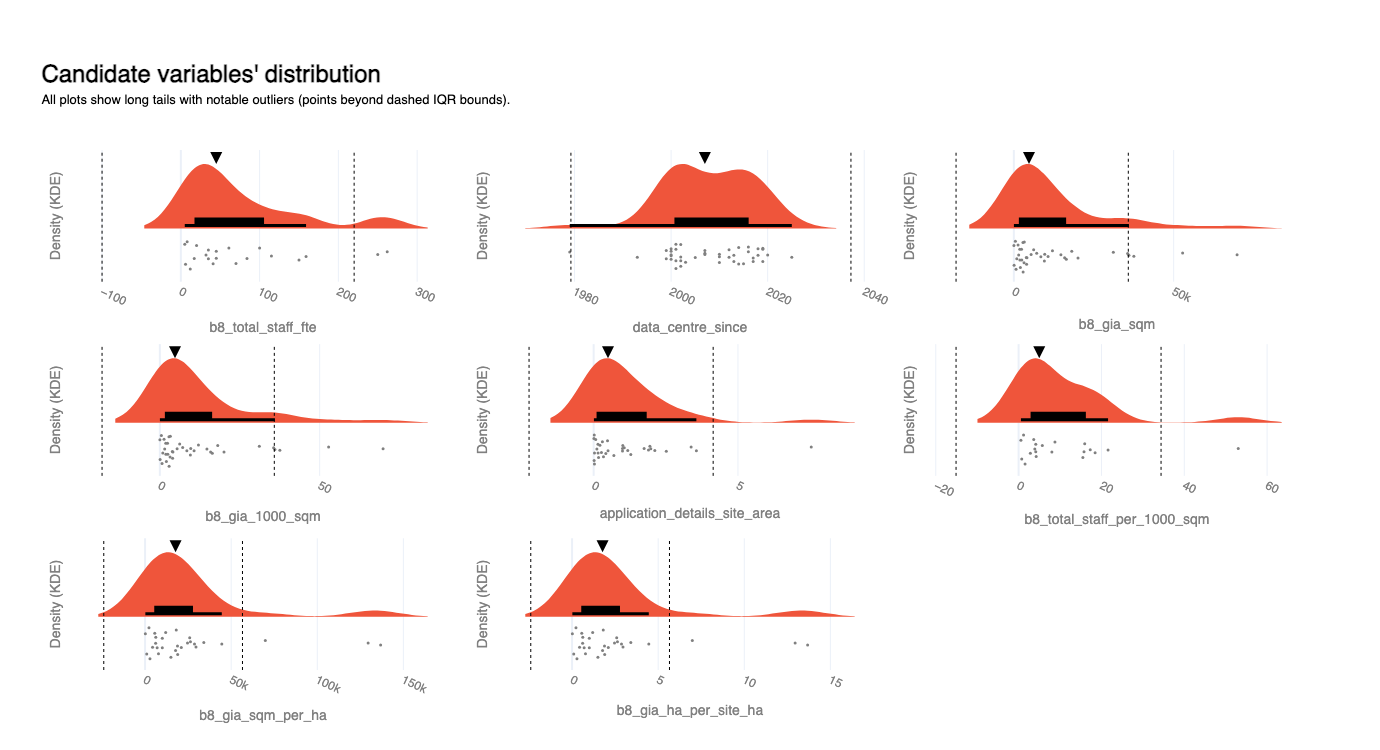

In [16]:
value_cols = ['b8_total_staff_fte', 'data_centre_since', 'b8_gia_sqm','b8_gia_1000_sqm', 'application_details_site_area', 'b8_total_staff_per_1000_sqm', 'b8_gia_sqm_per_ha', 'b8_gia_ha_per_site_ha']
cols_to_show = ['id', 'lpa_name'] + value_cols
df0 = data_ldn_exstg.copy()

n = len(value_cols)
ncols = 3
nrows = math.ceil(n / ncols)
fig = make_subplots(rows=nrows, cols=ncols, horizontal_spacing=0.05,vertical_spacing=0.12)
# _________________________________________________________________
# Violin plots
# _________________________________________________________________
for idx, value_col in enumerate(value_cols):
    r = idx // ncols + 1
    c = idx % ncols + 1
    df = df0.dropna(subset=[value_col]).copy()
    if df.empty:
        continue

    subset_customdata = df[cols_to_show].to_numpy()
    hovertemplate = "<br>".join([f"{col}: %{{customdata[{i}]}}" for i, col in enumerate(cols_to_show)])
    median_value = df[value_col].median()

    # # IQR bounds. Using the IQR, the outlier data points are the ones falling below Q1–1.5 IQR or above Q3 + 1.5 IQR: https://careerfoundry.com/en/blog/data-analytics/how-to-find-outliers/
    q1x, q3x = df[value_col].quantile([0.25, 0.75])
    iqrx = q3x - q1x
    low_x, high_x = q1x - 1.5 * iqrx, q3x + 1.5 * iqrx
    iqr_bounds = [low_x, high_x]

    # Auto bandwidth based on numeric range
    vmin, vmax = df[value_col].min(), df[value_col].max()
    rng = vmax - vmin
    if pd.isna(rng) or rng == 0:
        bw_bottom, bw_top = 1, 3
    else:
        bw_bottom = max(rng * 0.03, rng * 0.005)
        bw_top = max(rng * 0.10, rng * 0.02)

    fig.add_trace(go.Violin(
        x=df[value_col],orientation='h', side='positive', width=2, bandwidth=bw_top,line=dict(width=0),
        points="all",jitter=0.3, pointpos=-0.4, marker=dict(color='grey', size=3, opacity=1),
        box_visible=True, box_fillcolor='black', box_line=dict(color='black', width=3), box_width=0.2,
        fillcolor=base_color, showlegend=False, customdata=subset_customdata, hovertemplate=hovertemplate,
    ), row=r, col=c)
# _________________________________________________________________
# Helper elements
# _________________________________________________________________
    # IQR bounds
    for i, b in enumerate(iqr_bounds):
        fig.add_vline(x=b, line_width=1, line_dash="dot", line_color="black", row=r, col=c, showlegend=False)
        # invisible point just for hover
        fig.add_trace(go.Scatter(x=[b], y=[0],mode="markers", marker=dict(opacity=0),hovertemplate=f"IQR bound: {b:,.2f}<extra></extra>",showlegend=False,), row=r, col=c)

    # Median arrow
    fig.add_trace(go.Scatter(x=[median_value], mode='markers', marker=dict(symbol='arrow-down', color='black', size=12), showlegend=False,  hovertemplate="<br>".join([f"Median: {median_value}"])), row=r, col=c)
    
    # Style subplot axes
    fig.update_yaxes(showticklabels=False, title="Density (KDE)", ticks="", showgrid=False, zeroline=False, row=r, col=c)
    fig.update_xaxes(title_text=value_col, row=r, col=c)
    fig.update_xaxes(tickangle=25, tickfont=dict(color=labels_colour), title_font=dict(color=labels_colour))
    fig.update_yaxes(tickfont=dict(color=labels_colour), title_font=dict(color=labels_colour))

fig.update_layout(violinmode='overlay', width=1000, height=250 * nrows, template='plotly_white',
    title=dict(
        text=(
            f"<br><span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
            "Candidate variables' distribution"
            "</span><br>"
            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:0px;'>"
            "All plots show long tails with notable outliers (points beyond dashed IQR bounds)."
            "</span><br>"
        ),
        x=0.03, xanchor="left", y=0.92, yanchor="top",
    ),
    margin=dict(t=150),
)
fig.show()

Due to the low number of observations, we are applying a sequential approach, and aiming to have 1 explanatory variable per model. Outliers are identified and dropped individually for the model to maximise the number of observations.

The model scores had informed introduction of the new variables:
- first
- second

LIMITATION _ POTENTIAL OVERFITTING

In [17]:
# _________________________________________________________________
# Model 1: b8_total_staff_fte ~ b8_gia_1000_sqm
# _________________________________________________________________
value_cols_m1 = ['b8_total_staff_fte', 'b8_gia_1000_sqm']
data_ldn_exstg_regression_m1 = data_ldn_exstg.dropna(subset=value_cols_m1).copy()

for value_col in value_cols_m1:    
    #no outliers
    q1x, q3x = data_ldn_exstg_regression_m1[value_col].quantile([0.25, 0.75])
    iqrx = q3x - q1x
    low_x, high_x = q1x - 1.5 * iqrx, q3x + 1.5 * iqrx
    data_ldn_exstg_regression_m1 = data_ldn_exstg_regression_m1[data_ldn_exstg_regression_m1[value_col].between(low_x, high_x)]
    
    #log-transformation for testing with both
    data_ldn_exstg_regression_m1[f"log_{value_col}"] = np.log(data_ldn_exstg_regression_m1[value_col]+ 1e-6)

y = data_ldn_exstg_regression_m1["b8_total_staff_fte"]
X = sm.add_constant(data_ldn_exstg_regression_m1["b8_gia_1000_sqm"])

m1 = sm.OLS(y, X).fit()
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:     b8_total_staff_fte   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.281
Method:                 Least Squares   F-statistic:                     6.871
Date:                Sat, 17 Jan 2026   Prob (F-statistic):             0.0201
Time:                        02:00:24   Log-Likelihood:                -78.697
No. Observations:                  16   AIC:                             161.4
Df Residuals:                      14   BIC:                             162.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              17.0875     13.589     

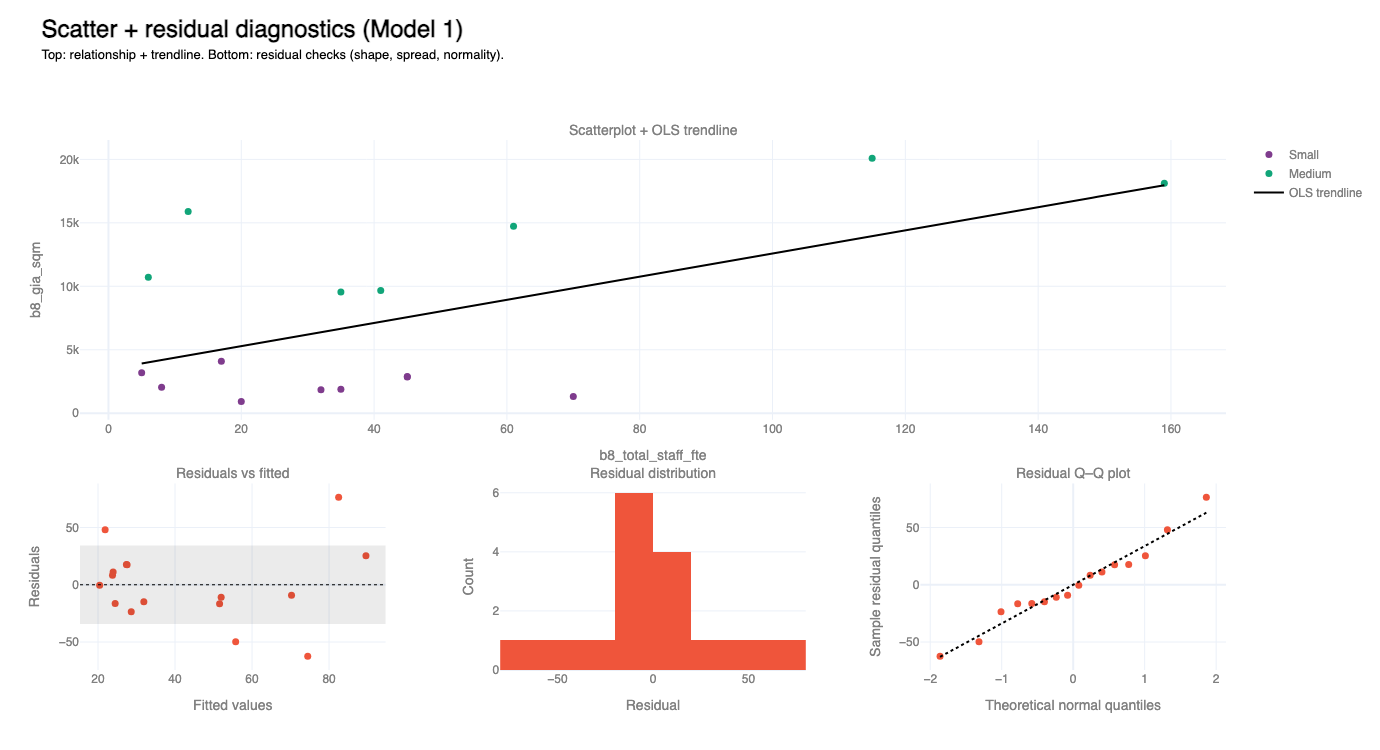

In [33]:
#______________________________________
# Inputs
#______________________________________
value_col_x = "b8_total_staff_fte"
value_col_y = "b8_gia_sqm"
df = data_ldn_exstg_regression_m1.copy()

notes_colour, labels_colour = "black", "grey"
cols_to_show = ["id","current_occupier","lpa_name","data_centre_since","b8_gia_sqm",
                "b8_total_staff_fte","b8_employees_at_a_day_estimate","total/day ratio"]

hovertemplate = "<br>".join([f"{c}: %{{customdata[{i}]}}" for i, c in enumerate(cols_to_show)]) + "<extra></extra>"
colors = px.colors.qualitative.Bold

#______________________________________
# Trendline (scatterplot)
#______________________________________
main_x, main_y = df[value_col_x], df[value_col_y]
m, c = np.polyfit(main_x.to_numpy(), main_y.to_numpy(), 1)
xt = np.linspace(main_x.min(), main_x.max(), 200)

#______________________________________
# Residuals from m1
#______________________________________
resid = m1.resid
fitted = m1.fittedvalues

tmp = df.copy()
tmp = tmp.assign(fitted=fitted.values, residual=resid.values)

# hover for residual plot = your usual + fitted + residual
cols_hover = cols_to_show + ["fitted", "residual"]
customdata_resid = tmp[cols_hover].to_numpy()
hovertemplate_resid = "<br>".join(
    [f"{col}: %{{customdata[{i}]}}" for i, col in enumerate(cols_hover)]
) + "<extra></extra>"

band = tmp["residual"].std()

#______________________________________
# Build subplots (2 rows x 3 cols)
#______________________________________
fig = make_subplots(
    rows=2, cols=3,
    row_heights=[0.60, 0.40],
    vertical_spacing=0.12,
    horizontal_spacing=0.10,
    specs=[
        [{"colspan": 3, "type": "xy"}, None, None],
        [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}],
    ],
    subplot_titles=[
        "Scatterplot + OLS trendline",
        "Residuals vs fitted",
        "Residual distribution",
        "Residual Q–Q plot"
    ]
)

fig.update_annotations(font=dict(size=14, color=labels_colour))

#==================================================================================================
# ROW 1 — Scatterplot (coloured by group) + trendline (full width)
#==================================================================================================
for i, band_name in enumerate(gia_labels):
    d = df[df["B8_gia_group"] == band_name]
    if d.empty:
        continue

    fig.add_trace(go.Scatter(
        x=d[value_col_x],
        y=d[value_col_y],
        mode="markers",
        marker=dict(size=7, color=colors[i % len(colors)]),
        customdata=d[cols_to_show].to_numpy(),
        hovertemplate=hovertemplate,
        name=str(band_name),
    ), row=1, col=1)

# OLS trendline
fig.add_trace(go.Scatter(
    x=xt,
    y=m * xt + c,
    mode="lines",
    line=dict(color="black", width=2),
    name="OLS trendline",
    hoverinfo="skip"
), row=1, col=1)

#==================================================================================================
# ROW 2 — Residual diagnostics
#==================================================================================================

# (1) Residuals vs fitted + shaded band
fig.add_trace(go.Scatter(
    x=tmp["fitted"],
    y=tmp["residual"],
    mode="markers",
    marker=dict(size=7, color=px.colors.qualitative.Plotly[1]),
    customdata=customdata_resid,
    hovertemplate=hovertemplate_resid,
    showlegend=False
), row=2, col=1)

fig.add_hrect(
    y0=-band, y1=band,
    fillcolor="rgba(0,0,0,0.08)",
    line_width=0,
    row=2, col=1
)

fig.add_hline(y=0, line_width=1, line_dash="dot", line_color="black", row=2, col=1)

# (2) Residual histogram
fig.add_trace(go.Histogram(
    x=tmp["residual"],
    nbinsx=12,
    marker=dict(color=px.colors.qualitative.Plotly[1]),
    hovertemplate="Residual: %{x:.2f}<br>Count: %{y}<extra></extra>",
    showlegend=False
), row=2, col=2)

# (3) Q–Q plot
resid_sorted = np.sort(tmp["residual"].to_numpy())
theoretical_q = stats.norm.ppf((np.arange(1, len(resid_sorted)+1) - 0.5) / len(resid_sorted))

slope, intercept = np.polyfit(theoretical_q, resid_sorted, 1)
fit_line = slope * theoretical_q + intercept

fig.add_trace(go.Scatter(
    x=theoretical_q,
    y=resid_sorted,
    mode="markers",
    marker=dict(size=7, color=px.colors.qualitative.Plotly[1]),
    hovertemplate="Theoretical Q: %{x:.2f}<br>Residual Q: %{y:.2f}<extra></extra>",
    showlegend=False
), row=2, col=3)

fig.add_trace(go.Scatter(
    x=theoretical_q,
    y=fit_line,
    mode="lines",
    line=dict(color="black", width=2, dash="dot"),
    hoverinfo="skip",
    showlegend=False
), row=2, col=3)

#______________________________________
# Layout
#______________________________________
fig.update_layout(
    width=1200,
    height=750,
    template="plotly_white",
    legend=dict(font=dict(color=labels_colour)),
    title=dict(
        text=(
            f"<br><span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block;'>"
            "Scatter + residual diagnostics (Model 1)"
            "</span><br>"
            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block;'>"
            "Top: relationship + trendline. Bottom: residual checks (shape, spread, normality)."
            "</span><br>"
        ),
        x=0.03, xanchor="left",
        y=0.98, yanchor="top"
    ),
    margin=dict(t=140),
)

#______________________________________
# Axis styling
#______________________________________

# Row 1 scatter
fig.update_xaxes(
    title_text=value_col_x,
    row=1, col=1,
    title_font=dict(color=labels_colour),
    tickfont=dict(color=labels_colour),
)
fig.update_yaxes(
    title_text=value_col_y,
    row=1, col=1,
    title_font=dict(color=labels_colour),
    tickfont=dict(color=labels_colour),
)

# Residuals vs fitted
fig.update_xaxes(title_text="Fitted values", row=2, col=1,
                 title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))
fig.update_yaxes(title_text="Residuals", row=2, col=1,
                 title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))

# Histogram
fig.update_xaxes(title_text="Residual", row=2, col=2,
                 title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))
fig.update_yaxes(title_text="Count", row=2, col=2,
                 title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))

# QQ plot
fig.update_xaxes(title_text="Theoretical normal quantiles", row=2, col=3,
                 title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))
fig.update_yaxes(title_text="Sample residual quantiles", row=2, col=3,
                 title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))

fig.show()

The model is staistically significant, and explains 32% of the observations.
Each 1000sqm of the data centre space creates 3.6 jobs, with std 1.4.
Residuals are mostly normally distributed.

The limitations are serious,
1. This is a small sample, and is prone to overfitting. We mitigated it by including only one variable, at the expense of the r2. Other variables were not statistically significant, and the interaction could not be explored due to the potential increased condition number and overfitting.
2. With all DC typologies included, the relationship may be not linear (provided only 1 explanatory variable is considered).
3. The model scatterplot shows the trendline exactly separating 2 identified types of data centres, and the position of the dots hints that different data centre typologies might have different relationship with the total_staff variable. LME model, or interaction term could be a solution, but a) the grouping currently is derived from the explanatory variable and b) the N of observations is restricting in terms of adding other variables.
**At this stage I will focus on manual search and filling in of the MW data for the observations in this model, to provide another categorisation source, and checking the gaps in the x/y variables.**
4. As can be seen from the output graphics, larger DC typologies were excluded due to being significant outliers. The data source is likely to not include all existing data centres, and therefore the outliers will likely stay as such and will be dropped. If non-linearity is suspected, we can't extend the coefficients onto the larger DC, and the calculations will only be applicable to the smaller facilities. **It is possible there are larger DC in the sample that have NaN x/y columns, and filling these in could improve the connection between groups. This re-validation could be done maually at this stage**
5. GIA is not always representative of the data hall space, which could provide a better comparison metric. It is, hovewer, hard to find using the planning data.
6. The data excludes Slough and other out-of-London clusters due to limitations of the planning database, so larger-scale new data centres are not being captured.

In [18]:
# _________________________________________________________________
# Model 2: b8_total_staff_fte ~ application_details_site_area
# _________________________________________________________________
value_cols_m2 = ['b8_total_staff_fte', 'application_details_site_area']
data_ldn_exstg_regression_m2 = data_ldn_exstg.dropna(subset=value_cols_m2).copy()

for value_col in value_cols_m2:    
    #no outliers
    q1x, q3x = data_ldn_exstg_regression_m2[value_col].quantile([0.25, 0.75])
    iqrx = q3x - q1x
    low_x, high_x = q1x - 1.5 * iqrx, q3x + 1.5 * iqrx
    data_ldn_exstg_regression_m2 = data_ldn_exstg_regression_m2[data_ldn_exstg_regression_m2[value_col].between(low_x, high_x)]
    
    #log-transformation for testing with both
    data_ldn_exstg_regression_m2[f"log_{value_col}"] = np.log(data_ldn_exstg_regression_m2[value_col]+ 1e-6)

y = data_ldn_exstg_regression_m2["b8_total_staff_fte"]
X = sm.add_constant(data_ldn_exstg_regression_m2["application_details_site_area"])

m2 = sm.OLS(y, X).fit()
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:     b8_total_staff_fte   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.077
Method:                 Least Squares   F-statistic:                  0.004580
Date:                Sat, 17 Jan 2026   Prob (F-statistic):              0.947
Time:                        02:00:24   Log-Likelihood:                -77.746
No. Observations:                  15   AIC:                             159.5
Df Residuals:                      13   BIC:                             160.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

In [19]:
# _________________________________________________________________
# Model 3: b8_total_staff_fte ~ data_centre_since_scaled
# _________________________________________________________________
value_cols_m3 = ['b8_total_staff_fte', 'data_centre_since_scaled']
data_ldn_exstg_regression_m3 = data_ldn_exstg.dropna(subset=value_cols_m3).copy()

for value_col in value_cols_m3:    
    #no outliers
    q1x, q3x = data_ldn_exstg_regression_m3[value_col].quantile([0.25, 0.75])
    iqrx = q3x - q1x
    low_x, high_x = q1x - 1.5 * iqrx, q3x + 1.5 * iqrx
    data_ldn_exstg_regression_m3 = data_ldn_exstg_regression_m3[data_ldn_exstg_regression_m3[value_col].between(low_x, high_x)]
    
    #log-transformation for testing with both
    data_ldn_exstg_regression_m3[f"log_{value_col}"] = np.log(data_ldn_exstg_regression_m3[value_col]+ 1e-6)

y = data_ldn_exstg_regression_m3["b8_total_staff_fte"]
X = sm.add_constant(data_ldn_exstg_regression_m3["data_centre_since_scaled"])

m3 = sm.OLS(y, X).fit()
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:     b8_total_staff_fte   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.000
Date:                Sat, 17 Jan 2026   Prob (F-statistic):              0.331
Time:                        02:00:24   Log-Likelihood:                -99.093
No. Observations:                  19   AIC:                             202.2
Df Residuals:                      17   BIC:                             204.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [20]:
# _________________________________________________________________
# Model 4: b8_total_staff_per_1000_sqm ~ data_centre_since_scaled
# _________________________________________________________________
value_cols_m4 = ['b8_total_staff_per_1000_sqm', 'data_centre_since_scaled']
data_ldn_exstg_regression_m4 = data_ldn_exstg.dropna(subset=value_cols_m4).copy()

for value_col in value_cols_m4:    
    #no outliers
    q1x, q3x = data_ldn_exstg_regression_m4[value_col].quantile([0.25, 0.75])
    iqrx = q3x - q1x
    low_x, high_x = q1x - 1.5 * iqrx, q3x + 1.5 * iqrx
    data_ldn_exstg_regression_m4 = data_ldn_exstg_regression_m4[data_ldn_exstg_regression_m4[value_col].between(low_x, high_x)]
    
    #log-transformation for testing with both
    data_ldn_exstg_regression_m4[f"log_{value_col}"] = np.log(data_ldn_exstg_regression_m4[value_col]+ 1e-6)

y = data_ldn_exstg_regression_m4["b8_total_staff_per_1000_sqm"]
X = sm.add_constant(data_ldn_exstg_regression_m4["data_centre_since_scaled"])

m4 = sm.OLS(y, X).fit()
print(m4.summary())

                                 OLS Regression Results                                
Dep. Variable:     b8_total_staff_per_1000_sqm   R-squared:                       0.074
Model:                                     OLS   Adj. R-squared:                  0.020
Method:                          Least Squares   F-statistic:                     1.362
Date:                         Sat, 17 Jan 2026   Prob (F-statistic):              0.259
Time:                                 02:00:24   Log-Likelihood:                -62.541
No. Observations:                           19   AIC:                             129.1
Df Residuals:                               17   BIC:                             131.0
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

In [21]:
data_ldn_exstg.describe()

,application_details_site_area,data_centre_since,b8_no_storeys,b8_max_height_m,b8_gia_sqm,b8_total_staff_fte,security_staff,cleaners_staff,managers_staff,site_engineers_staff,visitor_staff_not_on_site,cluster_staff_not_on_site,b8_employees_at_a_day_reported,total/day ratio,b8_employees_at_a_day_estimate,b8_gia_sqm_per_ha,b8_gia_ha_per_site_ha,b8_gia_1000_sqm,b8_total_staff_per_1000_sqm,data_centre_since_scaled
count,33.000000,43.000000,35.000000,25.000000,38.000000,21.000000,4.000000,3.000000,4.000000,3.000000,5.000000,1.0,8.000000,4.000000,7.000000,29.000000,29.000000,38.000000,20.000000,43.000000
mean,1.128070,2007.860465,4.057143,710.644920,12034.321979,73.904762,10.750000,4.333333,9.750000,31.333333,11.600000,13.0,37.750000,2.990000,28.857143,25339.304723,2.533930,12.034322,10.361863,29.860465
std,1.509598,9.030587,3.324976,3456.157457,15872.687514,75.262809,3.947573,2.886751,13.524669,30.615900,16.009372,NaN,33.225421,1.134578,23.448017,33372.722053,3.337272,15.872688,12.106936,9.030587
min,0.009000,1979.000000,1.000000,4.400000,24.000000,5.000000,5.000000,1.000000,2.000000,8.000000,1.000000,13.0,7.000000,1.970000,7.000000,155.844156,0.015584,0.024000,0.560224,1.000000
25%,0.154000,2001.000000,2.000000,7.800000,2130.750000,20.000000,10.250000,3.500000,2.750000,14.000000,5.000000,13.0,13.000000,2.307500,11.000000,6214.093960,0.621409,2.130750,3.458092,23.000000
50%,0.498300,2007.000000,2.000000,13.500000,4752.000000,45.000000,12.000000,6.000000,3.500000,20.000000,6.000000,13.0,25.500000,2.710000,20.000000,17710.849057,1.771085,4.752000,4.984382,29.000000
75%,1.749000,2015.500000,5.500000,29.753000,15601.500000,100.000000,12.500000,6.000000,10.500000,43.000000,6.000000,13.0,60.500000,3.392500,45.500000,26349.703641,2.634970,15.601500,15.832844,37.500000
max,7.540000,2025.000000,13.000000,17300.000000,69829.000000,262.000000,14.000000,6.000000,30.000000,66.000000,40.000000,13.0,100.000000,4.570000,62.000000,136800.000000,13.680000,69.829000,53.030303,47.000000


In [22]:
data_ldn_exstg.columns

Index(['lpa_name', 'uprn', 'decision_date', 'id', 'postcode', 'description',
       'last_updated', 'lpa_app_no', 'url_planning_app',
       'application_details_site_area', 'is_full_planning', 'geometry_point',
       'geometry', 'notes', 'enterprise', 'current_occupier', 'website',
       'address', 'data_centre_since', 'preapp_started', 'b8_no_storeys',
       'b8_max_height_m', 'b8_gia_sqm',
       'other_use_classes_present_within_b8_building', 'b8_total_staff_fte',
       'security_staff', 'cleaners_staff', 'managers_staff',
       'site_engineers_staff', 'visitor_staff_not_on_site',
       'cluster_staff_not_on_site', 'b8_employees_at_a_day_reported',
       'total/day ratio', 'b8_employees_at_a_day_estimate',
       'b8_gia_sqm_per_ha', 'b8_gia_ha_per_site_ha', 'b8_gia_1000_sqm',
       'b8_total_staff_per_1000_sqm', 'data_centre_since_scaled',
       'B8_gia_group'],
      dtype='object')

In [23]:
# _________________________________________________________________
# Model 5: b8_total_staff_fte ~ application_details_site_area
# _________________________________________________________________
value_cols_m5 = ['b8_total_staff_per_1000_sqm', 'application_details_site_area']
data_ldn_exstg_regression_m5 = data_ldn_exstg.dropna(subset=value_cols_m5).copy()

for value_col in value_cols_m5:    
    #no outliers
    q1x, q3x = data_ldn_exstg_regression_m5[value_col].quantile([0.25, 0.75])
    iqrx = q3x - q1x
    low_x, high_x = q1x - 1.5 * iqrx, q3x + 1.5 * iqrx
    data_ldn_exstg_regression_m5 = data_ldn_exstg_regression_m5[data_ldn_exstg_regression_m5[value_col].between(low_x, high_x)]
    
    #log-transformation for testing with both
    data_ldn_exstg_regression_m5[f"log_{value_col}"] = np.log(data_ldn_exstg_regression_m5[value_col]+ 1e-6)

y = data_ldn_exstg_regression_m5["b8_total_staff_per_1000_sqm"]
X = sm.add_constant(data_ldn_exstg_regression_m5["application_details_site_area"])

m5 = sm.OLS(y, X).fit()
print(m5.summary())

                                 OLS Regression Results                                
Dep. Variable:     b8_total_staff_per_1000_sqm   R-squared:                       0.010
Model:                                     OLS   Adj. R-squared:                 -0.060
Method:                          Least Squares   F-statistic:                    0.1457
Date:                         Sat, 17 Jan 2026   Prob (F-statistic):              0.708
Time:                                 02:00:24   Log-Likelihood:                -53.828
No. Observations:                           16   AIC:                             111.7
Df Residuals:                               14   BIC:                             113.2
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------

In [24]:
# _________________________________________________________________
# Model 6: b8_total_staff_fte ~ b8_gia_sqm_per_ha
# _________________________________________________________________
value_cols_m6 = ['b8_total_staff_fte', 'b8_gia_ha_per_site_ha']
data_ldn_exstg_regression_m6 = data_ldn_exstg.dropna(subset=value_cols_m6).copy()

for value_col in value_cols_m6:    
    #no outliers
    q1x, q3x = data_ldn_exstg_regression_m6[value_col].quantile([0.25, 0.75])
    iqrx = q3x - q1x
    low_x, high_x = q1x - 1.5 * iqrx, q3x + 1.5 * iqrx
    data_ldn_exstg_regression_m6 = data_ldn_exstg_regression_m6[data_ldn_exstg_regression_m6[value_col].between(low_x, high_x)]
    
    #log-transformation for testing with both
    data_ldn_exstg_regression_m6[f"log_{value_col}"] = np.log(data_ldn_exstg_regression_m6[value_col]+ 1e-6)

y = data_ldn_exstg_regression_m6["b8_total_staff_fte"]
X = sm.add_constant(data_ldn_exstg_regression_m6["b8_gia_ha_per_site_ha"])

m6 = sm.OLS(y, X).fit()
print(m6.summary())

                            OLS Regression Results                            
Dep. Variable:     b8_total_staff_fte   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                 -0.043
Method:                 Least Squares   F-statistic:                    0.4606
Date:                Sat, 17 Jan 2026   Prob (F-statistic):              0.510
Time:                        02:00:24   Log-Likelihood:                -74.137
No. Observations:                  14   AIC:                             152.3
Df Residuals:                      12   BIC:                             153.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    47.12

The distributions are far from normal, but it is time to run the models, and the assumptions can be addressed after.

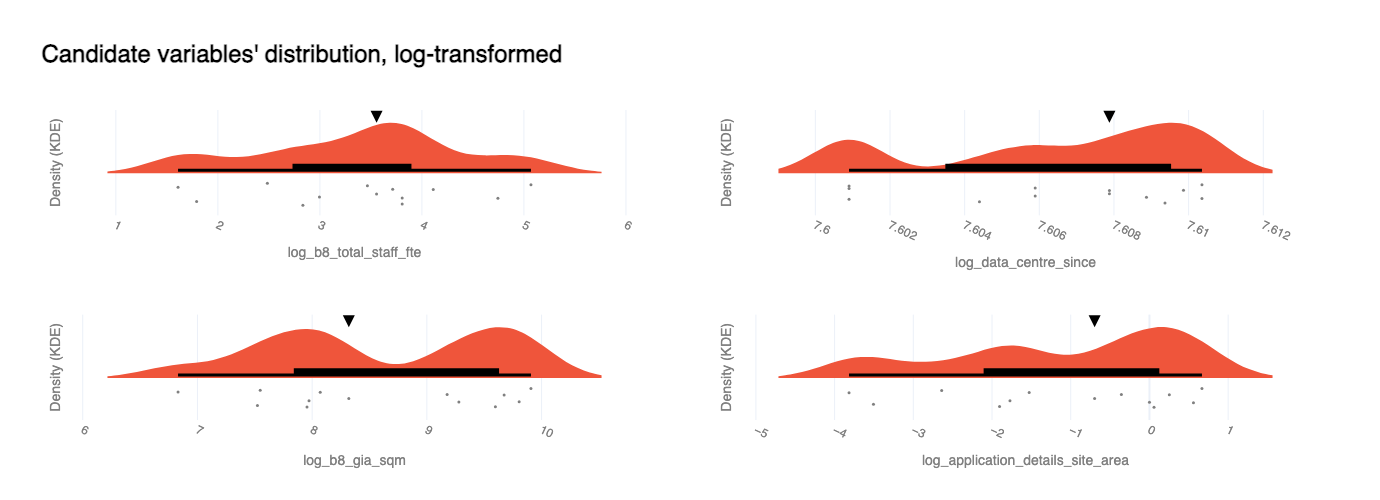

In [19]:
# # _________________________________________________________________
# # Plots kde curves again with log-transformed variables
# # _________________________________________________________________
# value_cols = ['log_b8_total_staff_fte', 'log_data_centre_since', 'log_b8_gia_sqm', 'log_application_details_site_area']
# cols_to_show = ['id', 'lpa_name'] + value_cols
# df0 = data_ldn_exstg_regression

# n = len(value_cols)
# ncols = 2
# nrows = math.ceil(n / ncols)
# fig = make_subplots(rows=nrows, cols=ncols, horizontal_spacing=0.10,vertical_spacing=0.32)
# # _________________________________________________________________
# # Violin plots
# # _________________________________________________________________
# for idx, value_col in enumerate(value_cols):
#     r = idx // ncols + 1
#     c = idx % ncols + 1
#     df = df0.dropna(subset=[value_col]).copy()
#     if df.empty:
#         continue

#     subset_customdata = df[cols_to_show].to_numpy()
#     hovertemplate = "<br>".join([f"{col}: %{{customdata[{i}]}}" for i, col in enumerate(cols_to_show)])
#     median_value = df[value_col].median()

#     # # # IQR bounds. Using the IQR, the outlier data points are the ones falling below Q1–1.5 IQR or above Q3 + 1.5 IQR: https://careerfoundry.com/en/blog/data-analytics/how-to-find-outliers/
#     # q1x, q3x = df[value_col].quantile([0.25, 0.75])
#     # iqrx = q3x - q1x
#     # low_x, high_x = q1x - 1.5 * iqrx, q3x + 1.5 * iqrx
#     # iqr_bounds = [low_x, high_x]

#     # Auto bandwidth based on numeric range
#     vmin, vmax = df[value_col].min(), df[value_col].max()
#     rng = vmax - vmin
#     if pd.isna(rng) or rng == 0:
#         bw_bottom, bw_top = 1, 3
#     else:
#         bw_bottom = max(rng * 0.03, rng * 0.005)
#         bw_top = max(rng * 0.10, rng * 0.02)

#     fig.add_trace(go.Violin(
#         x=df[value_col],orientation='h', side='positive', width=2, bandwidth=bw_top,line=dict(width=0),
#         points="all",jitter=0.3, pointpos=-0.4, marker=dict(color='grey', size=3, opacity=1),
#         box_visible=True, box_fillcolor='black', box_line=dict(color='black', width=3), box_width=0.2,
#         fillcolor=base_color, showlegend=False, customdata=subset_customdata, hovertemplate=hovertemplate,
#     ), row=r, col=c)
# # _________________________________________________________________
# # Helper elements
# # _________________________________________________________________
#     # # IQR bounds
#     # for i, b in enumerate(iqr_bounds):
#     #     fig.add_vline(x=b, line_width=1, line_dash="dot", line_color="black", row=r, col=c, showlegend=False)
#     #     # invisible point just for hover
#     #     fig.add_trace(go.Scatter(x=[b], y=[0],mode="markers", marker=dict(opacity=0),hovertemplate=f"IQR bound: {b:,.2f}<extra></extra>",showlegend=False,), row=r, col=c)

#     # Median arrow
#     fig.add_trace(go.Scatter(x=[median_value], mode='markers', marker=dict(symbol='arrow-down', color='black', size=12), showlegend=False,  hovertemplate="<br>".join([f"Median: {median_value}"])), row=r, col=c)
    
#     # Style subplot axes
#     fig.update_yaxes(showticklabels=False, title="Density (KDE)", ticks="", showgrid=False, zeroline=False, row=r, col=c)
#     fig.update_xaxes(title_text=value_col, row=r, col=c)
#     fig.update_xaxes(tickangle=25, tickfont=dict(color=labels_colour), title_font=dict(color=labels_colour))
#     fig.update_yaxes(tickfont=dict(color=labels_colour), title_font=dict(color=labels_colour))

# fig.update_layout(violinmode='overlay', width=1000, height=250 * nrows, template='plotly_white',
#     title=dict(
#         text=(
#             f"<br><span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
#             "Candidate variables' distribution, log-transformed"
#             "</span><br>"
#             # f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:0px;'>"
#             # "All plots show long tails with notable outliers (points beyond dashed IQR bounds)."
#             # "</span><br>"
#         ),
#         x=0.03, xanchor="left", y=0.92, yanchor="top",
#     ),
#     margin=dict(t=110),
# )
# fig.show()

In [75]:
# # Columns to show in hover
# df = data_ldn_exstg.dropna(subset=["total/day ratio", "B8_gia_group"])
# cols_to_show = ["id", "current_occupier", "b8_gia_sqm", "b8_total_staff_fte", "b8_employees_at_a_day_estimate", "B8_gia_group", "total/day ratio"]
# customdata = df[cols_to_show].to_numpy()
# colors = px.colors.qualitative.Bold

# hovertemplate = "<br>".join([
#     f"{col}: %{{customdata[{i}]}}" for i, col in enumerate(cols_to_show)
# ])

# # X and Y
# x = df["b8_gia_sqm"].values
# y = df["total/day ratio"].values

# # OLS fit (y = m*x + c)
# m, c = np.polyfit(x, y, 1)

# # Trendline values
# x_trend = np.linspace(x.min(), x.max(), 100)
# y_trend = m * x_trend + c

# #________________________________________________________________________________________________________________________________________________
# # Build Plot
# #________________________________________________________________________________________________________________________________________________
# fig = go.Figure()

# for i, band in enumerate(df["B8_gia_group"].dropna().unique()):
#     df_band = df[df["B8_gia_group"] == band]

#     fig.add_trace(go.Scatter(
#         x=df_band["b8_gia_sqm"],
#         y=df_band["total/day ratio"],
#         mode="markers",
#         marker=dict(
#             size=8,
#             color=colors[i % len(colors)],
#             showscale=False,
#         ),
#         customdata=df_band[cols_to_show].to_numpy(), 
#         hovertemplate=hovertemplate,
#         name=str(band)                                
#     ))

# # OLS trendline
# fig.add_trace(go.Scatter(
#     x=x_trend,
#     y=y_trend,
#     mode="lines",
#     line=dict(color="black", width=2),
#     name="OLS trendline"
# ))

# # -------------------------------------
# # Layout
# # -------------------------------------
# fig.update_layout(
#     title=(
#         f"<br><span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
#         "Total/daily staff ratio VS DC size"
#         "</span><br><br>"
#     ),
#     width=1000,
#     height=500,
#     template="plotly_white"
# )

# # Axis labels
# fig.update_xaxes(
#     title_text="Data centre size, GIA (sqm)",
#     title_font=dict(color=labels_colour),
#     tickfont=dict(color=labels_colour)
# )

# fig.update_yaxes(
#     title_text="Total/daily staff ratio",
#     title_font=dict(color=labels_colour),
#     tickfont=dict(color=labels_colour)
# )

# fig.show()

## Is the relationship between GIA and total staff N linear?

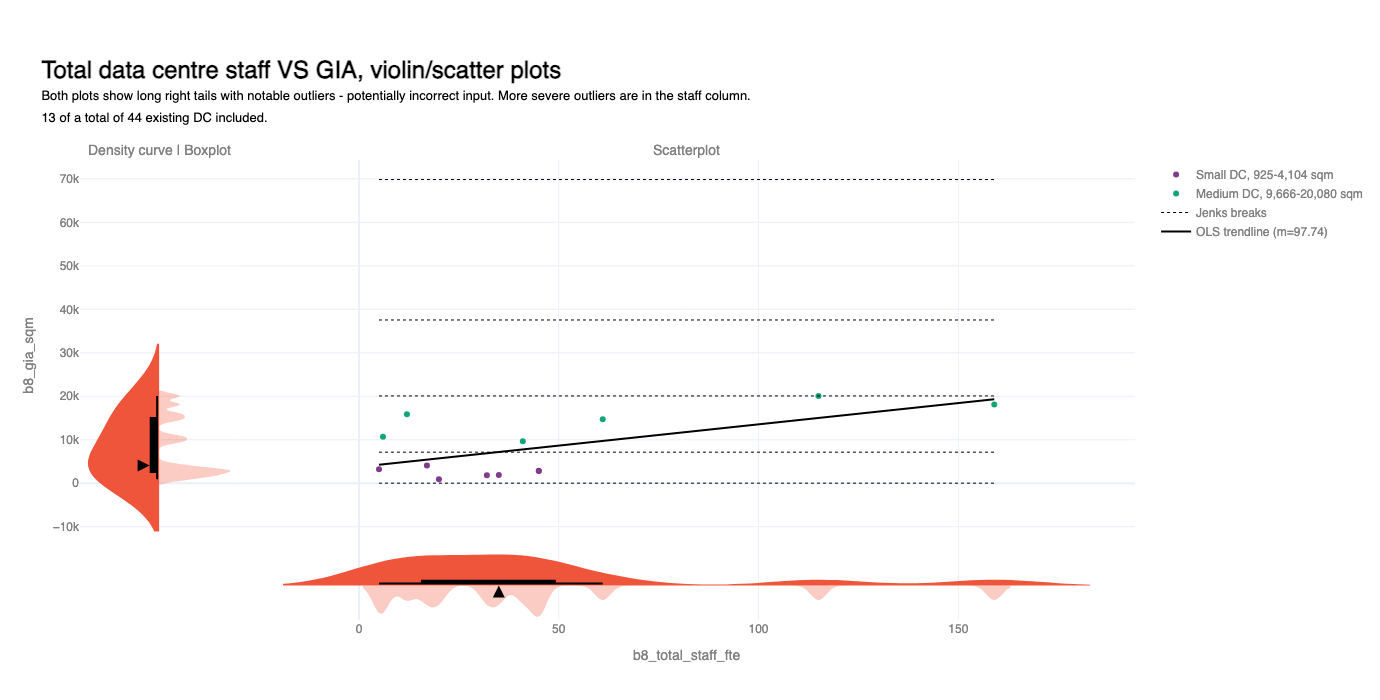

In [23]:
#________________________________________________________________________________________________________________________________________________
# Building violin plots/scatterplot to detect outliers. z-score can't be used because it is not normal distribution
#________________________________________________________________________________________________________________________________________________
value_col_x = "b8_total_staff_fte"
value_col_y = "b8_gia_sqm"

notes_colour, labels_colour = "black", "grey"
df = data_ldn_exstg_regression.dropna(subset=[value_col_x, value_col_y]).copy()

cols_to_show = ["id","current_occupier","lpa_name","data_centre_since","b8_gia_sqm",
                "b8_total_staff_fte","b8_employees_at_a_day_estimate","total/day ratio"]
hovertemplate = "<br>".join([f"{c}: %{{customdata[{i}]}}" for i, c in enumerate(cols_to_show)])

base_color, colors = px.colors.qualitative.Plotly[1], px.colors.qualitative.Bold
main_x, main_y = df[value_col_x], df[value_col_y]
median_value, median_x = main_y.median(), main_x.median()

fig = make_subplots(
    rows=2, cols=2, shared_yaxes=True, shared_xaxes=True,
    column_widths=[0.15, 0.85], row_heights=[0.85, 0.15],
    horizontal_spacing=0.0, vertical_spacing=0.0,
    subplot_titles=["Density curve | Boxplot", "Scatterplot", None, None],
    specs=[[{"type":"xy"},{"type":"xy"}],[{"type":"xy"},{"type":"xy"}]],
)
fig.update_annotations(font=dict(size=14, color=labels_colour))

#______________________________________
# Scatterplot
#______________________________________
for i, band in enumerate(gia_labels):
    d = df[df["B8_gia_group"] == band]
    if d.empty:
        continue

    fig.add_trace(go.Scatter(
        x=d[value_col_x], y=d[value_col_y], mode="markers",
        marker=dict(size=6, color=colors[i % len(colors)]),
        customdata=d[cols_to_show].to_numpy(), hovertemplate=hovertemplate,
        name=f"{band} DC, {int(d['b8_gia_sqm'].min()):,}-{int(d['b8_gia_sqm'].max()):,} sqm",
    ), row=1, col=2)

# Breaks
for i, b in enumerate(breaks):
    fig.add_trace(go.Scatter(
        x=[main_x.min(), main_x.max()], y=[b, b], mode="lines",line=dict(color="black", width=1, dash="dot"),
        name="Jenks breaks" if i == 0 else None,
        showlegend=(i == 0), hovertemplate=f"Jenks break<br>{value_col_y}: {b:,.0f}<br><extra></extra>",hoverinfo="text"
    ), row=1, col=2)
#______________________________________
# Density curves (LEFT - vertical violin for main_y)
#______________________________________
fig.add_trace(go.Violin(
    y=main_y, x0=1, orientation="v", side="positive", points=False, bandwidth=600, width=45, line=dict(width=0),fillcolor=make_transparent(base_color, 0.3),
    showlegend=False, hoverinfo="skip"
), row=1, col=1)

fig.add_trace(go.Violin(
    y=main_y, orientation="v", side="negative", points=False, width=45, bandwidth=6000, line=dict(width=0), box_visible=True, box_fillcolor="black",box_line=dict(color="black", width=2), box_width=0.18,
    fillcolor=base_color, showlegend=False, hoverinfo="skip"
), row=1, col=1)

fig.add_scatter(
    x=[-2], y=[median_value], mode="markers",
    marker=dict(symbol="arrow-right", color="black", size=12),
    showlegend=False, hoverinfo="skip"
)

#______________________________________
# Density curve (BOTTOM - horizontal violin for main_x)
#______________________________________
fig.add_trace(go.Violin(
    x=main_x, y0=0, orientation="h", side="negative", points=False,bandwidth=2, width=0.8, line=dict(width=0),fillcolor=make_transparent(base_color, 0.3),
    showlegend=False, hoverinfo="skip"
), row=2, col=2)

fig.add_trace(go.Violin(
    x=main_x, y0=0, orientation="h", side="positive", points=False,width=0.8, bandwidth=12, line=dict(width=0),
    box_visible=True, box_fillcolor="black", box_line=dict(color="black", width=2), box_width=0.18,fillcolor=base_color, showlegend=False, hoverinfo="skip"
), row=2, col=2)

fig.add_trace(go.Scatter(
    x=[median_x], y=[0], mode="markers", marker=dict(symbol="arrow-up", color="black", size=12), showlegend=False, hoverinfo="skip"
), row=2, col=2)

#______________________________________
# Trendline
#______________________________________
x, y = main_x.to_numpy(), main_y.to_numpy()
m, c = np.polyfit(x, y, 1)
xt = np.linspace(main_x.min(), main_x.max(), 100)
fig.add_trace(go.Scatter( x=xt, y=m*xt + c, mode="lines",line=dict(color="black", width=2),name=f"OLS trendline (m={m:.2f})"), row=1, col=2)

#______________________________________
# Layout updates - adding title and subtitle notes
#______________________________________
fig.update_layout(
    width=1000, height=700, template="plotly_white",
    title=dict(
        text=(
            f"<br><span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
            "Total data centre staff VS GIA, violin/scatter plots"
            "</span><br>"
            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:0px;'>"
            "Both plots show long right tails with notable outliers - potentially incorrect input. More severe outliers are in the staff column."
            "</span><br>"
            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:0px;'>"
            f"{len(df)} of a total of {len(data_ldn_exstg)} existing DC included."
            "</span><br>"
        ),
        x=0.03, xanchor="left", y=0.92, yanchor="top",
    ),
    margin=dict(t=160),
    legend=dict(font=dict(color=labels_colour))
)
fig.update_xaxes(title_text=value_col_x, row=2, col=2,title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))
fig.update_yaxes(title_text=value_col_y, row=1, col=1,title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))
fig.update_xaxes(showticklabels=False, row=1, col=1)
fig.update_yaxes(showticklabels=False, row=2, col=2)
fig.update_xaxes(visible=False, row=2, col=1)
fig.update_yaxes(visible=False, row=2, col=1)

fig.show()

In [31]:
# #________________________________________________________________________________________________________________________________________________
# # Building a kde curve to detect outliers. z-score can;t be used because it is not normal distribution
# #________________________________________________________________________________________________________________________________________________
# value_col = 'b8_total_staff_fte'
# cols_to_show = ['id', 'lpa_name', 'data_centre_since', 'b8_gia_sqm', 'b8_total_staff_fte']
# df = data_ldn_exstg.dropna(subset=[value_col]) # Drop missing
# median_value = df[value_col].median()
# base_color = px.colors.qualitative.Plotly[0]
# hovertemplate = "<br>".join([f"{col}: %{{customdata[{i}]}}" for i, col in enumerate(cols_to_show)])
# subset_customdata = df[cols_to_show].to_numpy()

# fig = go.Figure()
# fig = make_subplots(rows=2,cols=1,vertical_spacing=0.10)

# # Bottom transparent half
# fig.add_trace(go.Violin(x=df[value_col],orientation='h',side='negative',points=False,bandwidth=1.9, width=0.4,line=dict(width=0), fillcolor=make_transparent(base_color, alpha=0.3),
#     showlegend=False,customdata=subset_customdata,hovertemplate=hovertemplate, y0=1, 
# ))

# # Upper solid half + points + box
# fig.add_trace(go.Violin(x=df[value_col], orientation='h', side='positive', width=0.9, bandwidth=30, line=dict(width=0), 
#     points="all", jitter=0.3, pointpos=-0.4, marker=dict(color='grey', size=3, opacity=1),
#     box_visible=True, box_fillcolor='black', box_line=dict(color='black', width=2),box_width=0.1,fillcolor=base_color,
#     showlegend=False,customdata=subset_customdata,hovertemplate=hovertemplate,
# ))

# fig.add_scatter( x=[median_value], mode='markers',  marker=dict(symbol='arrow-down', color='black', size=12), showlegend=False,y0=1.03,)

# fig.update_layout(violinmode='overlay',width=1000, height=400,
#     yaxis=dict(showticklabels=False, ticks="", showgrid=False,zeroline=False, ),
#     template='plotly_white'
# )
# fig.update_layout(width=1000,height=300,template="plotly_white",
#     title=dict(
#         text=(
#             f"<br><span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
#             "Total data centre staff, violin plot"
#             "</span><br>"
#             f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:0px;'>"
#             "The plot shows a long right tail with notable outliers - potentially incorrect input."
#             "</span><br>"
#         ),x=0.03,xanchor="left",y=0.92,yanchor="top",), margin=dict(t=120),)

# fig.update_yaxes(title_text="Density (KDE)",title_font=dict(color=labels_colour),tickfont=dict(color=labels_colour))
# fig.update_xaxes(title_text="Total data centre staff",title_font=dict(color=labels_colour),tickfont=dict(color=labels_colour))
# fig.update_annotations(font=dict(size=14, color=labels_colour))

# fig.show()

In [ ]:
# IQR bounds for staff
q1x, q3x = df["b8_total_staff_fte"].quantile([0.25, 0.75])
iqrx = q3x - q1x
low_x, high_x = q1x - 1.5 * iqrx, q3x + 1.5 * iqrx

# IQR bounds for gia
q1y, q3y = df["b8_gia_sqm"].quantile([0.25, 0.75])
iqry = q3y - q1y
low_y, high_y = q1y - 1.5 * iqry, q3y + 1.5 * iqry

# keep only non-outliers in both columns
data_ldn_exstg = data_ldn_exstg[
    data_ldn_exstg[value_col_x].between(low_x, high_x)
    # & data_ldn_exstg[value_col_y].between(low_y, high_y)
].copy()

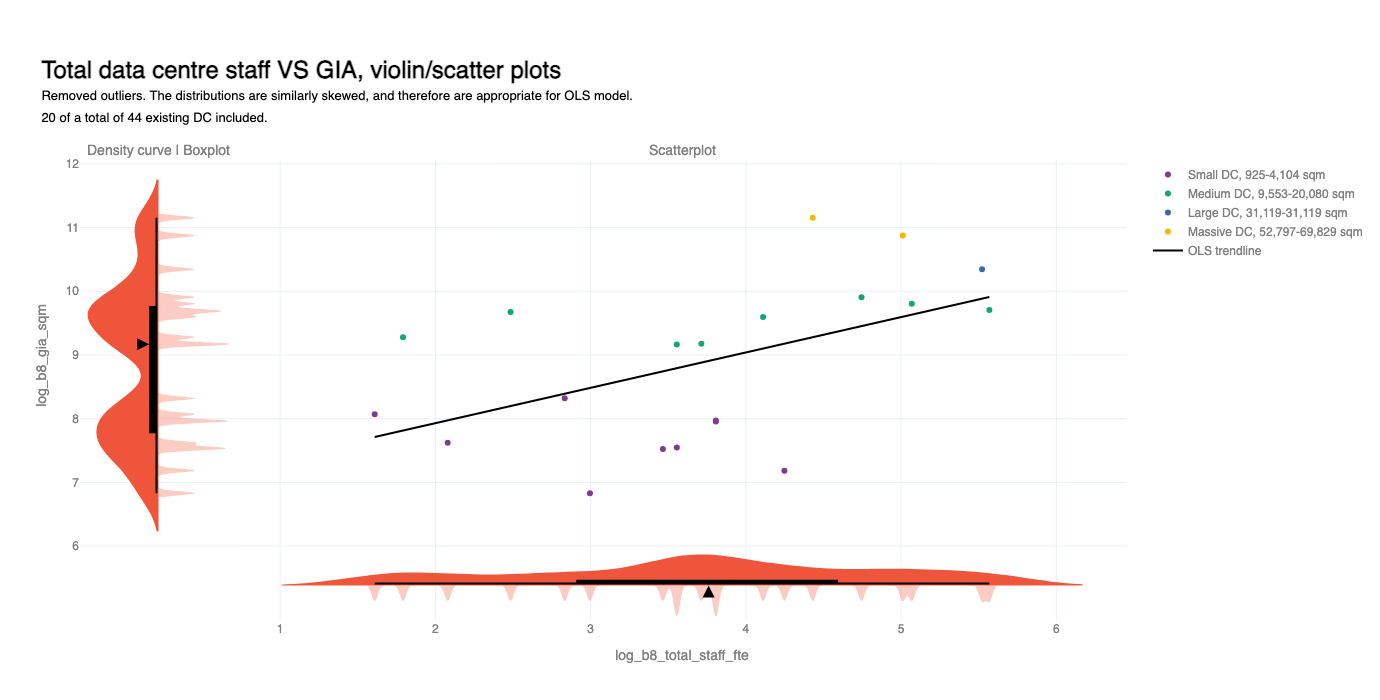

In [44]:
#________________________________________________________________________________________________________________________________________________
# Dropping outliers using IQR. https://careerfoundry.com/en/blog/data-analytics/how-to-find-outliers/
#________________________________________________________________________________________________________________________________________________
#log-transformation to make the distribution more normal
data_ldn_exstg["log_b8_gia_sqm"] = np.log(data_ldn_exstg["b8_gia_sqm"]) #we don't have 0 values, so no issues here
data_ldn_exstg["log_b8_total_staff_fte"] = np.log(data_ldn_exstg["b8_total_staff_fte"]) #we don't have 0 values, so no issues here

value_col_x = "log_b8_total_staff_fte"
value_col_y = "log_b8_gia_sqm"

df = data_ldn_exstg_regression = data_ldn_exstg.dropna(subset=[value_col_x, value_col_y]).copy()

notes_colour, labels_colour = "black", "grey"
cols_to_show = ["id","current_occupier","lpa_name","data_centre_since","b8_gia_sqm",
                "b8_total_staff_fte","b8_employees_at_a_day_estimate","total/day ratio"]
hovertemplate = "<br>".join([f"{c}: %{{customdata[{i}]}}" for i, c in enumerate(cols_to_show)])

base_color, colors = px.colors.qualitative.Plotly[1], px.colors.qualitative.Bold
main_x, main_y = df[value_col_x], df[value_col_y]
median_value, median_x = main_y.median(), main_x.median()

fig = make_subplots(
    rows=2, cols=2, shared_yaxes=True, shared_xaxes=True,
    column_widths=[0.15, 0.85], row_heights=[0.85, 0.15],
    horizontal_spacing=0.0, vertical_spacing=0.0,
    subplot_titles=["Density curve | Boxplot", "Scatterplot", None, None],
    specs=[[{"type":"xy"},{"type":"xy"}],[{"type":"xy"},{"type":"xy"}]],
)
fig.update_annotations(font=dict(size=14, color=labels_colour))

#______________________________________
# Scatterplot
#______________________________________
for i, band in enumerate(gia_labels):
    d = df[df["B8_gia_group"] == band]
    if d.empty:
        continue

    fig.add_trace(go.Scatter(
        x=d[value_col_x], y=d[value_col_y], mode="markers",
        marker=dict(size=6, color=colors[i % len(colors)]),
        customdata=d[cols_to_show].to_numpy(), hovertemplate=hovertemplate,
        name=f"{band} DC, {int(d['b8_gia_sqm'].min()):,}-{int(d['b8_gia_sqm'].max()):,} sqm",
    ), row=1, col=2)

# # Breaks
# for i, b in enumerate(breaks):
#     fig.add_trace(go.Scatter(
#         x=[main_x.min(), main_x.max()], y=[b, b], mode="lines",line=dict(color="black", width=1, dash="dot"),
#         name="Jenks breaks" if i == 0 else None,
#         showlegend=(i == 0), hovertemplate=f"Jenks break<br>{value_col_y}: {b:,.0f}<br><extra></extra>",hoverinfo="text"
#     ), row=1, col=2)
#______________________________________
# Density curves (LEFT - vertical violin for main_y)
#______________________________________
fig.add_trace(go.Violin(
    y=main_y, x0=1, orientation="v", side="positive", points=False, bandwidth=0.03, width=45, line=dict(width=0),fillcolor=make_transparent(base_color, 0.3),
    showlegend=False, hoverinfo="skip"
), row=1, col=1)

fig.add_trace(go.Violin(
    y=main_y, orientation="v", side="negative", points=False, width=45, bandwidth=0.3, line=dict(width=0), box_visible=True, box_fillcolor="black",box_line=dict(color="black", width=2), box_width=0.18,
    fillcolor=base_color, showlegend=False, hoverinfo="skip"
), row=1, col=1)

fig.add_scatter(
    x=[-2], y=[median_value], mode="markers",
    marker=dict(symbol="arrow-right", color="black", size=12),
    showlegend=False, hoverinfo="skip"
)

#______________________________________
# Density curve (BOTTOM - horizontal violin for main_x)
#______________________________________
fig.add_trace(go.Violin(
    x=main_x, y0=0, orientation="h", side="negative", points=False,bandwidth=0.02, width=0.8, line=dict(width=0),fillcolor=make_transparent(base_color, 0.3),
    showlegend=False, hoverinfo="skip"
), row=2, col=2)

fig.add_trace(go.Violin(
    x=main_x, y0=0, orientation="h", side="positive", points=False,width=0.8, bandwidth=0.3, line=dict(width=0),
    box_visible=True, box_fillcolor="black", box_line=dict(color="black", width=2), box_width=0.18,fillcolor=base_color, showlegend=False, hoverinfo="skip"
), row=2, col=2)

fig.add_trace(go.Scatter(
    x=[median_x], y=[0], mode="markers", marker=dict(symbol="arrow-up", color="black", size=12), showlegend=False, hoverinfo="skip"
), row=2, col=2)

#______________________________________
# Trendline
#______________________________________
x, y = main_x.to_numpy(), main_y.to_numpy()
m, c = np.polyfit(x, y, 1)
xt = np.linspace(main_x.min(), main_x.max(), 100)
fig.add_trace(go.Scatter( x=xt, y=m*xt + c, mode="lines",line=dict(color="black", width=2),name=f"OLS trendline"), row=1, col=2)

#______________________________________
# Layout updates - adding title and subtitle notes
#______________________________________
fig.update_layout(
    width=1000, height=700, template="plotly_white",
    title=dict(
        text=(
            f"<br><span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
            "Total data centre staff VS GIA, violin/scatter plots"
            "</span><br>"
            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:0px;'>"
            "Removed outliers. The distributions are similarly skewed, and therefore are appropriate for OLS model."
            "</span><br>"
            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:0px;'>"
            f"{len(df)} of a total of {len(data_ldn_exstg)} existing DC included."
            "</span><br>"
        ),
        x=0.03, xanchor="left", y=0.92, yanchor="top",
    ),
    margin=dict(t=160),
    legend=dict(font=dict(color=labels_colour))
)
fig.update_xaxes(title_text=value_col_x, row=2, col=2,title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))
fig.update_yaxes(title_text=value_col_y, row=1, col=1,title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))
fig.update_xaxes(showticklabels=False, row=1, col=1)
fig.update_yaxes(showticklabels=False, row=2, col=2)
fig.update_xaxes(visible=False, row=2, col=1)
fig.update_yaxes(visible=False, row=2, col=1)

fig.show()

In [ ]:
value_col_x = "log_b8_total_staff_fte"
value_col_y = "log_b8_gia_sqm"

data_ldn_exstg_regression = data_ldn_exstg.dropna(subset=["log_b8_total_staff_fte", "log_b8_gia_sqm"]).copy()

#no outliers
data_ldn_exstg_regression = data_ldn_exstg_regression[
    data_ldn_exstg_regression[value_col_x].between(low_x, high_x)
    # & data_ldn_exstg_regression[value_col_y].between(low_y, high_y)
    ]

y = data_ldn_exstg_regression["log_b8_total_staff_fte"]
X = sm.add_constant(data_ldn_exstg_regression["log_b8_gia_sqm"])

gia_vs_totstaff_model = sm.OLS(y, X).fit()
print(gia_vs_totstaff_model.summary())

In [ ]:
#________________________________________________________________________________________________________________________________________________
# HISTOGRAMS
#________________________________________________________________________________________________________________________________________________

df = data_ldn_exstg.dropna(subset=["b8_gia_sqm", "b8_total_staff_fte"])
fig = make_subplots(rows=1,cols=2,horizontal_spacing=0.10)
fig.add_trace(go.Histogram(x=df["b8_gia_sqm"],nbinsx=20,marker=dict(color=px.colors.qualitative.Bold[0]),name="GIA (sqm)",showlegend=False), row=1, col=1)
fig.add_trace(go.Histogram(x=df["b8_total_staff_fte"],nbinsx=20,marker=dict(color=px.colors.qualitative.Bold[1]),name="Total staff (FTE)",showlegend=False), row=1, col=2)
fig.update_layout(width=1000,height=300,template="plotly_white",
    title=dict(
        text=(
            f"<br><span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
            "Distribution of data centre size and total staff numbers"
            "</span><br><br>"
        ),x=0.03,xanchor="left",y=0.92,yanchor="top",), margin=dict(t=120),)

fig.update_xaxes(title_text="Data centre size, GIA (sqm)",row=1, col=1,title_font=dict(color=labels_colour),tickfont=dict(color=labels_colour))
fig.update_xaxes(title_text="Total staff (FTE)",row=1, col=2,title_font=dict(color=labels_colour),tickfont=dict(color=labels_colour))
fig.update_yaxes(title_text="Count of observations",row=1, col=1,title_font=dict(color=labels_colour),tickfont=dict(color=labels_colour))
fig.update_annotations(font=dict(size=14, color=labels_colour))
fig.show()

#________________________________________________________________________________________________________________________________________________
# the distribution is skewed. Taking log to normalise
#________________________________________________________________________________________________________________________________________________
data_ldn_exstg["log_b8_gia_sqm"] = np.log(data_ldn_exstg["b8_gia_sqm"]) #we don't have 0 values, so no issues here
data_ldn_exstg["log_b8_total_staff_fte"] = np.log(data_ldn_exstg["b8_total_staff_fte"]) #we don't have 0 values, so no issues here
df = data_ldn_exstg.dropna(subset=["log_b8_gia_sqm", "log_b8_total_staff_fte"])

fig = make_subplots(rows=1,cols=2,horizontal_spacing=0.10)
fig.add_trace(go.Histogram(x=df["log_b8_gia_sqm"],nbinsx=20,marker=dict(color=px.colors.qualitative.Bold[0]),name="log GIA (sqm)",showlegend=False), row=1, col=1)
fig.add_trace(go.Histogram(x=df["log_b8_total_staff_fte"],nbinsx=20,marker=dict(color=px.colors.qualitative.Bold[1]),name="log Total staff (FTE)",showlegend=False), row=1, col=2)
fig.update_layout(width=1000,height=300,template="plotly_white",
    title=dict(
        text=(
            f"<br><span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
            "Distribution of data centre size and total staff numbers: log-transformed"
            "</span><br><br>"
        ),x=0.03,xanchor="left",y=0.92,yanchor="top",), margin=dict(t=120),)

fig.update_xaxes(title_text="log Data centre size",row=1, col=1,title_font=dict(color=labels_colour),tickfont=dict(color=labels_colour))
fig.update_xaxes(title_text="log Total staff",row=1, col=2,title_font=dict(color=labels_colour),tickfont=dict(color=labels_colour))
fig.update_yaxes(title_text="Count of observations",row=1, col=1,title_font=dict(color=labels_colour),tickfont=dict(color=labels_colour))
fig.update_annotations(font=dict(size=14, color=labels_colour))
fig.show()

In [25]:
#taking a non-null subset
gia_vs_totstaff = data_ldn_exstg.dropna(subset=["log_b8_gia_sqm", "log_b8_total_staff_fte"])

# Define independent and dependent variables
X = sm.add_constant(gia_vs_totstaff['log_b8_total_staff_fte'])  # adds intercept
y = gia_vs_totstaff["log_b8_gia_sqm"]

gia_vs_totstaff_model = sm.OLS(y, X).fit()

# Print summary
print(gia_vs_totstaff_model.summary())

                            OLS Regression Results                            
Dep. Variable:         log_b8_gia_sqm   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.223
Method:                 Least Squares   F-statistic:                     6.451
Date:                Fri, 16 Jan 2026   Prob (F-statistic):             0.0205
Time:                        01:39:25   Log-Likelihood:                -29.464
No. Observations:                  20   AIC:                             62.93
Df Residuals:                      18   BIC:                             64.92
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      6

## LME model

A Linear Mixed Effects (LME) model is a more general class of statistical
model that features both a fixed-effects component (the population-
average parameters) and a random-effects component (the group-specific
deviations)

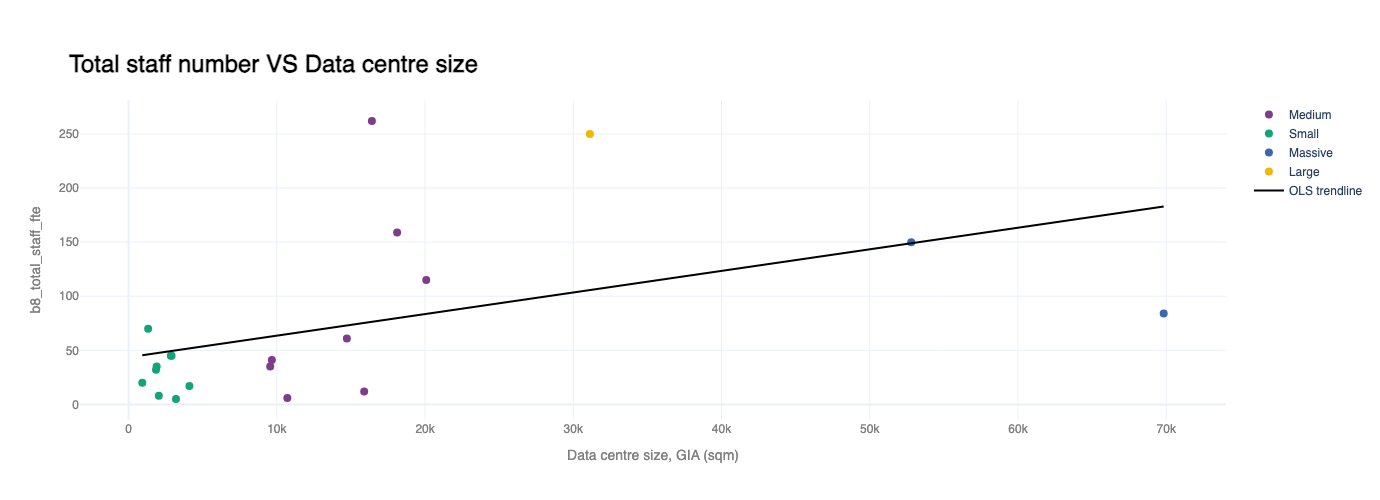

In [26]:
# Columns to show in hover
df = data_ldn_exstg.dropna(subset=["b8_gia_sqm", "b8_total_staff_fte"])
cols_to_show = ["id", "current_occupier", "b8_gia_sqm", "b8_total_staff_fte", "b8_employees_at_a_day_estimate", "B8_gia_group", "total/day ratio", "data_centre_since"]
customdata = df[cols_to_show].to_numpy()
colors = px.colors.qualitative.Bold

hovertemplate = "<br>".join([
    f"{col}: %{{customdata[{i}]}}" for i, col in enumerate(cols_to_show)
])

x = df["b8_gia_sqm"].values
y = df["b8_total_staff_fte"].values
m, c = np.polyfit(x, y, 1)
# Trendline values
x_trend = np.linspace(x.min(), x.max(), 100)
y_trend = m * x_trend + c

#________________________________________________________________________________________________________________________________________________
# Build Plot
#________________________________________________________________________________________________________________________________________________
fig = go.Figure()

for i, band in enumerate(df["B8_gia_group"].dropna().unique()):
    df_band = df[df["B8_gia_group"] == band]

    fig.add_trace(go.Scatter(
        x=df_band["b8_gia_sqm"],
        y=df_band["b8_total_staff_fte"],
        mode="markers",
        marker=dict(
            size=8,
            color=colors[i % len(colors)],
            showscale=False,
        ),
        customdata=df_band[cols_to_show].to_numpy(), 
        hovertemplate=hovertemplate,
        name=str(band)                                
    ))

# OLS trendline
fig.add_trace(go.Scatter(
    x=x_trend,
    y=y_trend,
    mode="lines",
    line=dict(color="black", width=2),
    name="OLS trendline"
))

# -------------------------------------
# Layout
# -------------------------------------
fig.update_layout(
    title=(
        f"<br><span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
        "Total staff number VS Data centre size"
        "</span><br><br>"
    ),
    width=1000,
    height=500,
    template="plotly_white"
)

# Axis labels
fig.update_xaxes(
    title_text="Data centre size, GIA (sqm)",
    title_font=dict(color=labels_colour),
    tickfont=dict(color=labels_colour)
)

fig.update_yaxes(
    title_text="b8_total_staff_fte",
    title_font=dict(color=labels_colour),
    tickfont=dict(color=labels_colour)
)

fig.show()

In [49]:
data_ldn_exstg["b8_employees_at_a_day_estimate"] = data_ldn_exstg["b8_employees_at_a_day_estimate"].where(
    data_ldn_exstg["b8_employees_at_a_day_estimate"].notna(),
    data_ldn_exstg["b8_total_staff_fte"] / data_ldn_exstg["total/day ratio"]
).round(0)

#________________________________________________________________________________________________________________________________________________
# b8_employees_at_a_day_estimate –> b8_total_staff_fte
# NOTE in some cases we had information about the N of daily staff (reported, not just estimates), but no information about total N of staff
# in these rows we will feed back the b8_employees_at_a_day_estimate into the total column
#________________________________________________________________________________________________________________________________________________

data_ldn_exstg["b8_total_staff_fte"] = data_ldn_exstg["b8_total_staff_fte"].where(
    data_ldn_exstg["b8_total_staff_fte"].isna(),
    data_ldn_exstg["b8_employees_at_a_day_estimate"] * data_ldn_exstg["total/day ratio"]
).round(0)

In [12]:
#__________________________________________________________________________________________________________________________________
# security_staff, cleaners_staff, managers_staff, site_engineers_staff, visitor_staff_not_on_site
# NOTE sometimes the categories are not reported, so we will calculate % of all types of occupations 
# of total number by GIA group, and impute as with previous example.
# security_staff, cleaners_staff will be joined into one category. Often site security N is provided, but N of cleaners is not
#__________________________________________________________________________________________________________________________________
data_ldn_exstg["security_cleaners_staff"] = data_ldn_exstg["security_staff"] + data_ldn_exstg["cleaners_staff"]
data_ldn_exstg["perc_security_cleaners_staff"] = data_ldn_exstg["security_cleaners_staff"] / (data_ldn_exstg["b8_total_staff_fte"] / 100)
data_ldn_exstg[data_ldn_exstg["security_cleaners_staff"].notna()==True][["B8_gia_group", "security_cleaners_staff", "perc_security_cleaners_staff"]]

,B8_gia_group,security_cleaners_staff,perc_security_cleaners_staff
20,Large,6.0,NaN
48,Medium,18.0,43.902439
51,Small,18.0,56.250000


In [13]:
data_ldn_exstg[data_ldn_exstg["security_cleaners_staff"].notna()==True]

,lpa_name,uprn,decision_date,id,postcode,description,last_updated,lpa_app_no,url_planning_app,application_details_site_area,is_full_planning,geometry_point,geometry,notes,enterprise,current_occupier,website,address,data_centre_since,preapp_started,b8_no_storeys,b8_max_height_m,b8_gia_sqm,other_use_classes_present_within_b8_building,b8_total_staff_fte,security_staff,cleaners_staff,managers_staff,site_engineers_staff,visitor_staff_not_on_site,cluster_staff_not_on_site,b8_employees_at_a_day_reported,total/day ratio,b8_employees_at_a_day_estimate,B8_gia_group,security_cleaners_staff,perc_security_cleaners_staff
20,Havering,NaN,29/2/2012,Havering-P0151_12,RM7 7PN,Amendments to planning permission P1290.07 (as...,NaN,P0151.12,https://development.havering.gov.uk/OcellaWeb/...,3.5600,NaN,NaN,NaN,Planning permission was originally approved un...,False,Green Mountain,https://greenmountain.no/data-center/lon-east/,"3 King George Close, Romford London RM7 7PN",2007.0,NaN,2.0,13.500,35600.0,NaN,NaN,5.0,1.0,4.0,8.0,NaN,NaN,60.0,NaN,60.0,Large,6.0,NaN
48,Tower Hamlets,6155368,13/12/2013,Tower_Hamlets-PA_13_00803,E14,Change of use from business (Use Class B1) to ...,2025-08-14T12:59:01.405+01:00,PA/13/00803,https://development.towerhamlets.gov.uk/online...,0.2170,True,POINT (-0.0182919 51.4968331),"POLYGON ((537681.7463894 179423.0578592, 53767...",NaN,False,Digital Realty,https://www.digitalrealty.com/data-centers/eme...,"Archway House, 1 Muirfield Crescent and 47 Mil...",2014.0,NaN,7.0,30.000,9666.0,NaN,41.0,12.0,6.0,3.0,20.0,NaN,NaN,NaN,1.97,21.0,Medium,18.0,43.902439
51,Tower Hamlets,6151764,27/5/2021,Tower_Hamlets-PA_21_00615_NC,E1 6QL,Erection of 14 no. 1.2m diameter satellite dis...,2025-12-28T20:59:31.892Z,PA/21/00615/NC,https://development.towerhamlets.gov.uk/online...,0.0714,True,POINT (-0.072453 51.52125),POINT (-0.072453 51.52125),NaN,False,Digital Realty,https://www.digitalrealty.com/data-centers/eme...,"Block D, Trumans Brewery, 91 Brick Lane, Londo...",2019.0,NaN,6.0,29.753,1850.0,NaN,32.0,12.0,6.0,NaN,NaN,1.0,13.0,7.0,4.57,7.0,Small,18.0,56.250000


In [11]:
# data_ldn_exstg

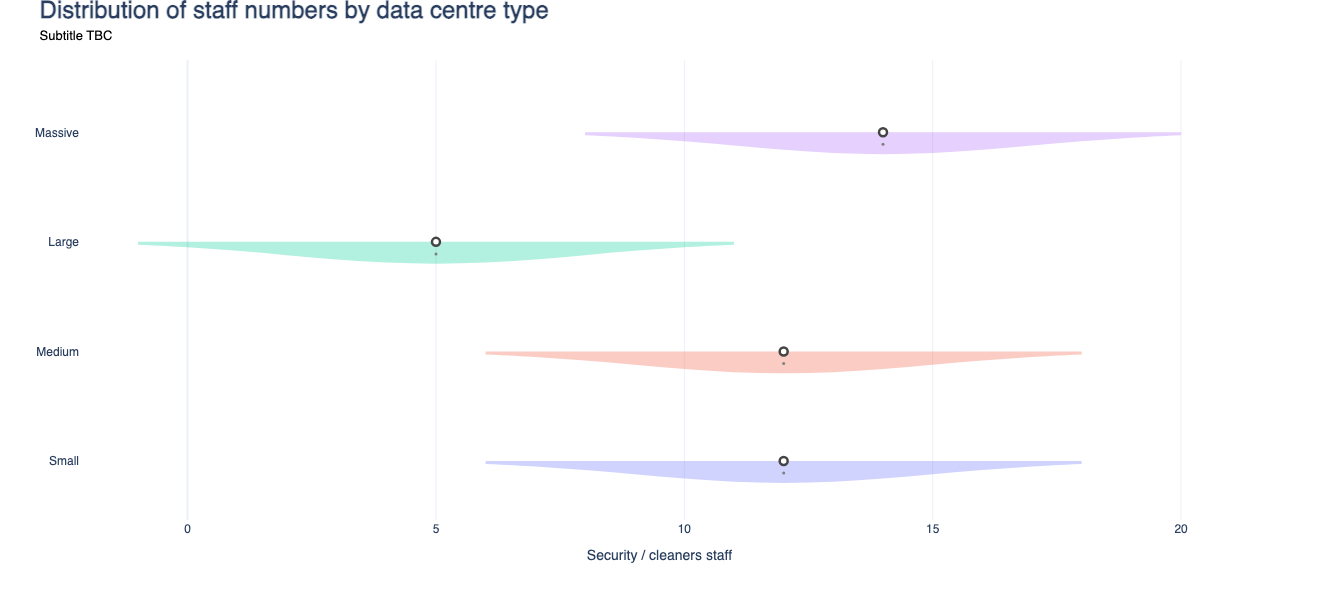

In [53]:
# -------------------------------------
# Explicit categories (size bands)
# ______________________________________
df = data_ldn_exstg
value_col = "security_staff"
cats_col = "B8_gia_group"

# enforce order (optional but recommended)
cats = ["Small", "Medium", "Large", "Massive"]

palette = px.colors.qualitative.Plotly
color_map = {cat: palette[i % len(palette)] for i, cat in enumerate(cats)}

# -------------------------------------
# Build figure
# -------------------------------------
fig = go.Figure()

for cat in cats:
    subset = df[df[cats_col] == cat].dropna(subset=[value_col])

    # Left half-violin (transparent)
    fig.add_trace(go.Violin(
        y=[cat] * len(subset),
        x=subset[value_col],
        orientation="h",
        side="negative",
        points=False,
        bandwidth=3,
        width=0.4,
        line=dict(width=0),
        fillcolor=make_transparent(color_map[cat], alpha=0.3),
        showlegend=False,
    ))

    # Right half-violin (solid + points + box)
    fig.add_trace(go.Violin(
        y=[cat] * len(subset),
        x=subset[value_col],
        orientation="h",
        side="positive",
        width=0.9,
        line=dict(width=0),
        points="all",
        jitter=0.3,
        pointpos=-0.4,
        marker=dict(color="grey", size=3),
        box_visible=True,
        box_fillcolor="black",
        box_line=dict(color="black", width=2),
        box_width=0.1,
        fillcolor=color_map[cat],
        showlegend=False,
    ))

# -------------------------------------
# Median markers
# -------------------------------------
medians = (
    df.dropna(subset=[cats_col, value_col])
    .groupby(cats_col, observed=True)[value_col]
    .median()
    .reindex(cats)
    .reset_index()
)

fig.add_scatter(
    x=medians[value_col],
    y=medians[cats_col],
    mode="markers",
    marker=dict(
        symbol="circle",
        color="white",
        size=8,
        line=dict(width=2.5),
    ),
    showlegend=False,
)

# -------------------------------------
# Layout
# -------------------------------------
fig.update_layout(
    violinmode="overlay",
    width=1000,
    height=600,
    xaxis=dict(
        title="Security / cleaners staff",
    ),
    yaxis=dict(
        title=None,
        categoryorder="array",
        categoryarray=cats,
        showgrid=False,
    ),
    template="plotly_white",
    title=dict(
        text=(
            "<span style='font-size:24px; font-weight:700;'>"
            "Distribution of staff numbers by data centre type"
            "</span><br>"
            "<span style='font-size:13px; font-weight:300; color:black;'>"
            "Subtitle TBC"
            "</span>"
        ),
        x=0.03,
        xanchor="left",
        y=0.97,
        yanchor="top",
    ),
    margin=dict(t=60),
)

fig.show()

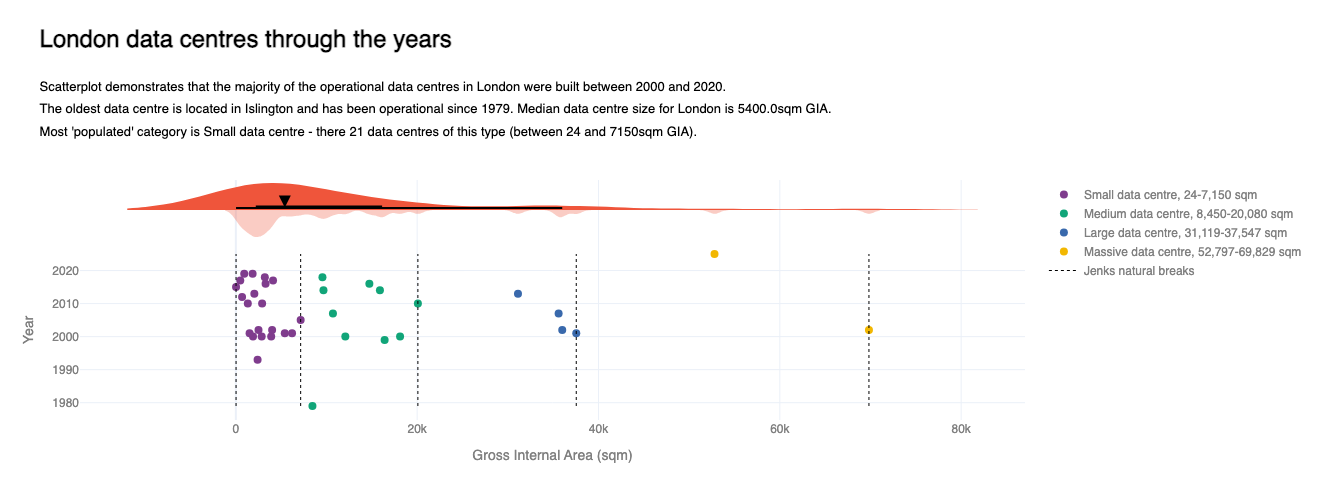

In [257]:
#______________________________________
# Build subplots
#______________________________________

notes_colour = "black"
labels_colour = "grey"

df = data_ldn_exstg.dropna(subset=["b8_gia_sqm", "data_centre_since"]).copy()
# df = df.sort_values(by="data_centre_since", ascending=True)

cols_to_show = ["id", "current_occupier", "lpa_name", "data_centre_since", "b8_gia_sqm", "b8_total_staff_fte", "b8_employees_at_a_day_estimate", "total/day ratio"]
customdata = df[cols_to_show].to_numpy()
base_color = px.colors.qualitative.Plotly[1]
# base_color = "grey"
colors = px.colors.qualitative.Bold

main_x = df["b8_gia_sqm"]
main_y = df["data_centre_since"]

median_value = main_x.median()

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    row_heights=[0.25, 0.75],
    vertical_spacing=0.00
)

#______________________________________
# Scatterplot
#______________________________________
bands_sorted = sorted(df["B8_gia_group"].dropna().unique())

for i, band in enumerate(gia_labels):
    df_band = df[df["B8_gia_group"] == band]

    fig.add_trace(go.Scatter(
        x=df_band["b8_gia_sqm"],
        y=df_band["data_centre_since"],
        mode="markers",
        marker=dict(
            size=8,
            color=colors[i % len(colors)],
        ),
        customdata=df_band[cols_to_show].to_numpy(),
        hovertemplate=hovertemplate,
        name=f"{band} data centre, {int(df.loc[df["B8_gia_group"] == band, "b8_gia_sqm"].min()):,}-{int(df.loc[df["B8_gia_group"] == band, "b8_gia_sqm"].max()):,} sqm",
    ), row=2, col=1)

# Breaks
for i, b in enumerate(breaks):
    fig.add_trace(go.Scatter(
        x=[b, b],
        y=[main_y.min(), main_y.max()],
        mode="lines",
        line=dict(color="black", width=1, dash="dot"),
        name="Jenks natural breaks" if i == 0 else None,
        showlegend=True if i == 0 else False,
        hovertemplate=(
            f"Jenks break<br>"
            f"GIA boundary: {b:,.0f} sqm<br>"
            "<extra></extra>"
        ),
        hoverinfo="text"
    ), row=2, col=1)

#______________________________
# Density curves
#______________________________________

# bottom
fig.add_trace(go.Violin(
    x=main_x,
    y0=1,
    orientation="h", 
    side="negative", 
    points=False, 
    bandwidth=600, 
    width=45, 
    line=dict(width=0), 
    fillcolor=make_transparent(base_color, alpha=0.3), 
    showlegend=False, 
    hoverinfo="skip" 
), row=1, col=1)

# top
fig.add_trace(go.Violin(
    x=main_x,
    orientation="h",
    side="positive",
    width=45,
    bandwidth=6000,
    line=dict(width=0),
    points=False,
    box_visible=True,
    box_fillcolor="black",
    box_line=dict(color="black", width=2),
    box_width=0.12,
    fillcolor=base_color,
    showlegend=False,
    hoverinfo="skip",
), row=1, col=1)

# median
fig.add_scatter(
    x=[median_value],
    # y=[0],
    mode='markers',
    marker=dict(symbol='arrow-down', color='black', size=12),
    showlegend=False,
    y0=3,
)

#______________________________________
# Layout updates - adding title and subtitle notes
#______________________________________
fig.update_layout(
    width=1000,
    height=500,
    template="plotly_white",

    title=dict(
       text=(
            f"<br><span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:4px;'>"
            "London data centres through the years"
            "</span><br><br>"
        
            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:2px;'>"
            "Scatterplot demonstrates that the majority of the operational data centres in London were built between 2000 and 2020."
            "</span><br>"
        
            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block;'>"
            f"The oldest data centre is located in {df.loc[main_y.idxmin(), 'lpa_name']} and has been operational since {int(main_y.min())}. "
            f"Median data centre size for London is {median_value}sqm GIA."
            "</span><br>"

            f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block;'>"
            f"Most 'populated' category is {df["B8_gia_group"].value_counts().idxmax()} data centre - there {df["B8_gia_group"].value_counts().max()} data centres of this type (between {int(df.loc[df["B8_gia_group"] == "Small", "b8_gia_sqm"].min())} and {int(df.loc[df["B8_gia_group"] == "Small", "b8_gia_sqm"].max())}sqm GIA)."
            "</span><br>"
        ),

        x=0.03,
        xanchor="left",
        y=0.95,
        yanchor="top",
    ),
    margin=dict(t=180),

    legend=dict(
        font=dict(color=labels_colour)
    )
)

# Axis labels
fig.update_yaxes(title_text="Year", row=2, col=1, title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))
fig.update_xaxes(title_text="Gross Internal Area (sqm)", row=2, col=1, title_font=dict(color=labels_colour), tickfont=dict(color=labels_colour))
fig.update_yaxes(showticklabels=False, row=1, col=1)

fig.show()

In [214]:
# ____________________________________________________
# Filtered by availability of total/daily ration
# ____________________________________________________
data_ldn_total_daily = data_ldn.dropna(subset=["total/day ratio"])

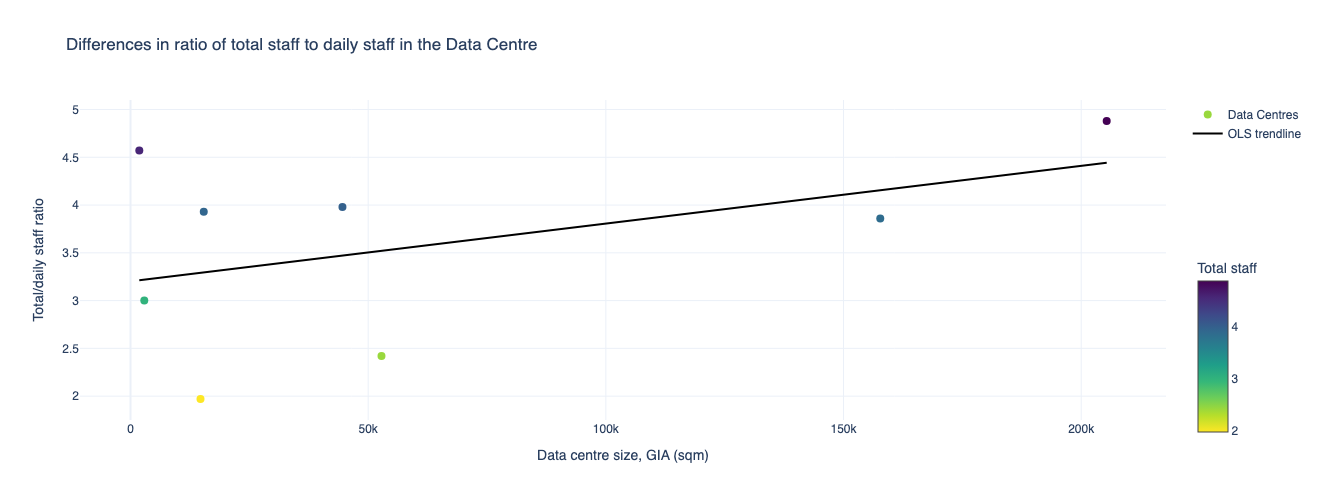

In [30]:
# Columns to show in hover
cols_to_show = ["id", "current_occupier", "lpa_name", "data_centre_since", "b8_gia_sqm", "b8_total_staff_fte", "b8_employees_at_a_day_estimate", "total/day ratio"]
customdata = data_ldn_total_daily[cols_to_show].to_numpy()

hovertemplate = "<br>".join([
    f"{col}: %{{customdata[{i}]}}" for i, col in enumerate(cols_to_show)
])

# X and Y
x = data_ldn_total_daily["b8_gia_sqm"].values
y = data_ldn_total_daily["total/day ratio"].values

# OLS fit (y = m*x + c)
m, c = np.polyfit(x, y, 1)

# Trendline values
x_trend = np.linspace(x.min(), x.max(), 100)
y_trend = m * x_trend + c

# -------------------------------------
# Build Plot
# -------------------------------------
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=data_ldn_total_daily["b8_gia_sqm"],
    y=data_ldn_total_daily["total/day ratio"],
    mode="markers",
    marker=dict(
        size=8,
        color=data_ldn_total_daily["total/day ratio"],
        colorscale="Viridis_r",
        showscale=True,
        colorbar=dict(title="Total staff", len=0.6, xanchor="left", yanchor="top", y=0.53)
    ),
    customdata=customdata,
    hovertemplate=hovertemplate,
    name="Data Centres"
))

# OLS trendline
fig.add_trace(go.Scatter(
    x=x_trend,
    y=y_trend,
    mode="lines",
    line=dict(color="black", width=2),
    name="OLS trendline"
))

# -------------------------------------
# Layout
# -------------------------------------
fig.update_layout(
    title="Differences in ratio of total staff to daily staff in the Data Centre",
    xaxis_title="Data centre size, GIA (sqm)",
    yaxis_title="Total/daily staff ratio",
    width=1000,
    height=500,
    template="plotly_white"
)

fig.show()

In [ ]:
I am determining the clusters of data centre size and total/daily ratio to identify an average ratio per size band. 

In [31]:
len(data_ldn)

65

In [17]:
print(f"B8 use GIA range is {data_ldn["b8_gia_sqm"].max() - data_ldn["b8_gia_sqm"].min()} sqm.")

B8 use GIA range is 205341.0 sqm.


I will be using k-neighbours clustering to identify types of data centres by size using b8_gia_sqm clolumn – Gross Internal Area of the B8 use within the data centre block. There are 7 null values in this column, and imputation would not result in reliable numbers since they are not dependent on any other known variable. Therefore, for this step, I will work on a subset without NA values.

I will be using several variables in the k-means, and first i need to fill in the missing values in the employees' column.

1. A few of the DC entries have the total and daily staff numbers included within the planning application or on the website. I am using the average ratio of 

In [ ]:
scaler = StandardScaler()

scaled_array = scaler.fit_transform(df_reduced_imputed)

df_scaled = pd.DataFrame(
    scaled_array,
    columns=cols_for_clustering,
    index=df_school_london.index
)

df_scaled.describe().T

In [238]:
# # Columns to show in hover
# cols_to_show = [
#     "id", "current_occupier", "lpa_name",
#     "data_centre_since", "b8_gia_sqm", "b8_total_staff_fte"
# ]
# customdata = data_ldn_date[cols_to_show].to_numpy()

# hovertemplate = "<br>".join([
#     f"{col}: %{{customdata[{i}]}}" for i, col in enumerate(cols_to_show)
# ])

# # -------------------------------------
# # Build Plot
# # -------------------------------------
# fig = go.Figure()

# # --- Scatter plot ---
# fig.add_trace(go.Scatter(
#     x=data_ldn_date["data_centre_since"],
#     y=data_ldn_date["b8_gia_sqm"],
#     mode="markers",
#     marker=dict(
#         size=8,
#         color=data_ldn_date["b8_total_staff_fte"],
#         colorscale="Viridis_r",
#         showscale=True,
#         colorbar=dict(title="Total staff")
#     ),
#     customdata=customdata,
#     hovertemplate=hovertemplate,
#     name="Data Centre"
# ))

# # -------------------------------------
# # Half violin on top (right side only)
# # -------------------------------------
# y_top = data_ldn_date["b8_gia_sqm"].max() * 1.05

# fig.add_trace(go.Violin(
#     x=data_ldn_date["data_centre_since"],
#     y=[y_top] * len(data_ldn_date),     # fixed vertical position
#     orientation="h",
#     side="positive",                    # right half only
#     width=y_top * 0.08,                 # visual thickness
#     points=False,
#     line=dict(width=0),
#     fillcolor="rgba(80,80,80,0.4)",
#     showlegend=False,
# ))

# # -------------------------------------
# # Layout
# # -------------------------------------
# fig.update_layout(
#     title="Growth of data centre size over time",
#     xaxis_title="Year",
#     yaxis_title="Gross Internal Area (sqm)",
#     width=1000,
#     height=600,
#     template="plotly_white"
# )

# # Make room for the violin
# fig.update_yaxes(range=[0, y_top * 1.15])

# fig.show()


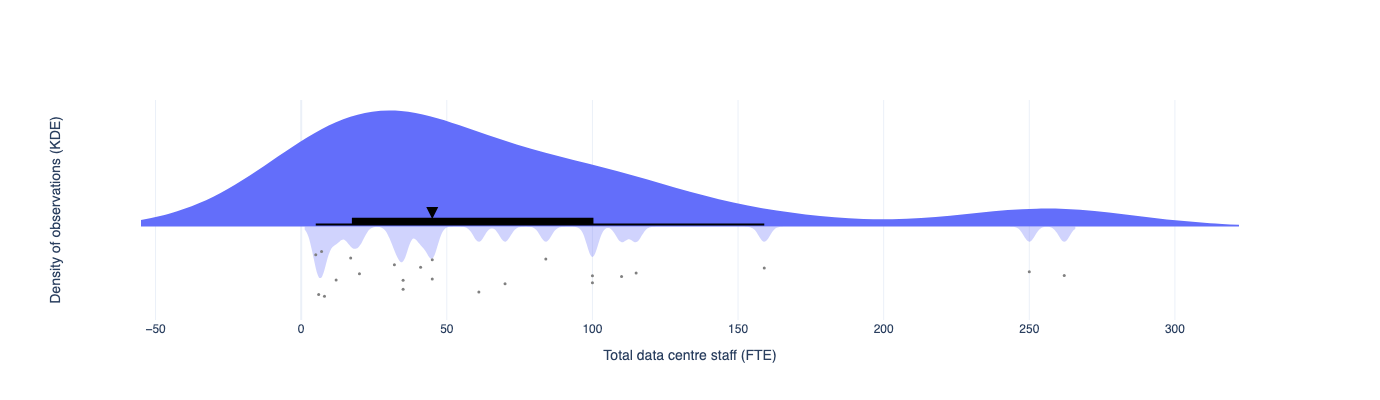

In [115]:
# -------------------------------------
# Set variables
# -------------------------------------
value_col = 'b8_total_staff_fte'
cols_to_show = ['id', 'lpa_name', 'data_centre_since', 'b8_gia_sqm', 'b8_total_staff_fte']

# Drop missing
df = data_ldn_date.dropna(subset=[value_col])

# -------------------------------------
# Compute median
# -------------------------------------
median_value = df[value_col].median()

# -------------------------------------
# Colour
# -------------------------------------
base_color = px.colors.qualitative.Plotly[0]

# Helper: convert rgb/hex to transparent rgba
def make_transparent(color, alpha=0.3):
    if color.startswith("rgb"):
        return color.replace(")", f", {alpha})").replace("rgb", "rgba")
    elif color.startswith("#"):
        r, g, b = tuple(int(color[i:i+2], 16) for i in (1, 3, 5))
        return f"rgba({r},{g},{b},{alpha})"
    return color

# -------------------------------------
# Build figure
# -------------------------------------
fig = go.Figure()

subset_customdata = df[cols_to_show].to_numpy()

hovertemplate = "<br>".join(
    [f"{col}: %{{customdata[{i}]}}" for i, col in enumerate(cols_to_show)]
)

# -------------------------------------
# Bottom transparent half
# -------------------------------------
fig.add_trace(go.Violin(
    x=df[value_col],
    orientation='h',
    side='negative',
    points=False,
    bandwidth=1.9,
    width=0.4,
    line=dict(width=0),
    fillcolor=make_transparent(base_color, alpha=0.3),
    showlegend=False,
    customdata=subset_customdata,
    hovertemplate=hovertemplate,
    y0=1, 
))

# -------------------------------------
# Upper solid half + points + box
# -------------------------------------
fig.add_trace(go.Violin(
    x=df[value_col],
    orientation='h',
    side='positive',
    width=0.9,
    bandwidth=30,
    line=dict(width=0),
    points="all",
    jitter=0.3,
    pointpos=-0.4,
    marker=dict(color='grey', size=3, opacity=1),
    box_visible=True,
    box_fillcolor='black',
    box_line=dict(color='black', width=2),
    box_width=0.1,
    fillcolor=base_color,
    showlegend=False,
    customdata=subset_customdata,
    hovertemplate=hovertemplate,
))

# -------------------------------------
# Median arrow
# -------------------------------------
fig.add_scatter(
    x=[median_value],
    # y=[0],
    mode='markers',
    marker=dict(symbol='arrow-down', color='black', size=12),
    showlegend=False,
    y0=1.03,
)

# -------------------------------------
# Layout (with density label)
# -------------------------------------
fig.update_layout(
    violinmode='overlay',
    width=1000,
    height=400,
    xaxis_title="Total data centre staff (FTE)",
    yaxis=dict(
        showticklabels=False,
        title="Density of observations (KDE)",
        ticks="",             
        showgrid=False,
        zeroline=False,            
    ),
    template='plotly_white'
)


fig.show()

In [117]:
# data_ldn_date

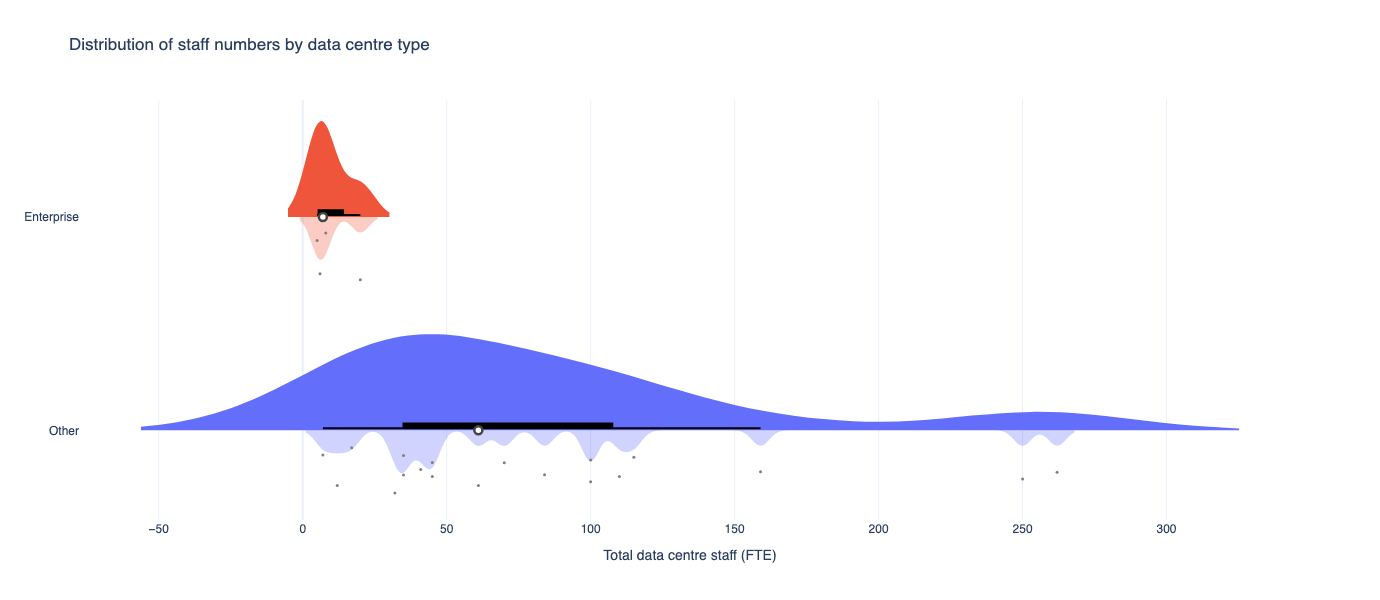

In [186]:
# -------------------------------------
# Explicit categories (boolean)
# -------------------------------------
categories = [False, True]

palette = px.colors.qualitative.Plotly
color_map = {
    False: palette[0],
    True: palette[1],
}

# Helper function to convert hex or rgb to rgba with desired alpha
def make_transparent(color, alpha=0.2):
    if color.startswith("rgb"):
        return color.replace(")", f", {alpha})").replace("rgb", "rgba")
    elif color.startswith("#"):
        r, g, b = tuple(int(color[i:i+2], 16) for i in (1, 3, 5))
        return f"rgba({r},{g},{b},{alpha})"
    return color

# -------------------------------------
# Build figure
# -------------------------------------
fig = go.Figure()

for cat in categories:
    subset = data_ldn_date[data_ldn_date['enterprise'] == cat]

    # Left half-violin (transparent)
    fig.add_trace(go.Violin(
        y=[cat] * len(subset),                     # ← critical
        x=subset['b8_total_staff_fte'],
        orientation='h',
        side='negative',
        points=False,
        bandwidth=3,
        width=0.4,
        line=dict(width=0),
        fillcolor=make_transparent(color_map[cat], alpha=0.3),
        showlegend=False,
    ))

    # Right half-violin (solid + points + box)
    fig.add_trace(go.Violin(
        y=[cat] * len(subset),                     # ← critical
        x=subset['b8_total_staff_fte'],
        orientation='h',
        side='positive',
        width=0.9,
        line=dict(width=0),
        points="all",
        jitter=0.3,
        pointpos=-0.4,
        marker=dict(color='grey', size=3),
        box_visible=True,
        box_fillcolor='black',
        box_line=dict(color='black', width=2),
        box_width=0.1,
        fillcolor=color_map[cat],
        showlegend=False,
    ))

# -------------------------------------
# Median arrows
# -------------------------------------
medians = (
    data_ldn_date
    .groupby('enterprise')['b8_total_staff_fte']
    .median()
    .reset_index()
)

fig.add_scatter(
    x=medians['b8_total_staff_fte'],
    y=medians['enterprise'],
    mode='markers',
    marker=dict(
        symbol='circle',   # horizontal line
        color='white',
        size=8,
        line=dict(width=2.5),
    ),
    showlegend=False,
)

# -------------------------------------
# Layout
# -------------------------------------
fig.update_layout(
    title="Distribution of staff numbers by data centre type",
    violinmode='overlay',
    width=1000,
    height=600,
    xaxis=dict(
        title="Total data centre staff (FTE)",
        # range=[0, None],       
    ),
    yaxis=dict(
        title=None,
        tickvals=[False, True],  
        ticktext=["Other", "Enterprise"],  # labels shown
        categoryorder="array",
        categoryarray=[False, True],  # explicit order
        showgrid=False,
    ),
    template='plotly_white',
)

fig.show()

In [14]:
data_ldn_size["b8_gia_sqm"].describe()

count        58.000000
mean      22278.826934
std       37393.369201
min           0.027000
25%        2568.750000
50%        9001.500000
75%       26506.000000
max      205365.000000
Name: b8_gia_sqm, dtype: float64

In [ ]:
# Get unique categories and assign a color palette
categories = england_filtered_regression['gor_name_'].unique()
palette = px.colors.qualitative.Plotly  # built-in Plotly qualitative palette
color_map = {cat: palette[i % len(palette)] for i, cat in enumerate(categories)}

# Helper function to convert hex or rgb to rgba with desired alpha
def make_transparent(color, alpha=0.2):
    if color.startswith("rgb"):  # already rgb string
        return color.replace(")", f", {alpha})")
    elif color.startswith("#"):  # hex to rgba
        r, g, b = tuple(int(color[i:i+2], 16) for i in (1, 3, 5))
        return f"rgba({r},{g},{b},{alpha})"
    else:
        return color  # fallback

fig = go.Figure()

for cat in categories:
    subset = england_filtered_regression[england_filtered_regression['gor_name_'] == cat]
    
    # Left half-violin (negative side) with transparency
    fig.add_trace(go.Violin(
        y=subset['gor_name_'],
        x=subset['PTFSM6CLA1A'],
        orientation='h',
        side='negative',
        points=False,
        bandwidth=0.5,             # smoothness for left half
        width=0.9,
        line=dict(width=0),
        # box_visible=True,
        fillcolor=make_transparent(color_map[cat], alpha=0.3),
        name=cat,
        showlegend=False
    ))
    
    # Right half-violin (positive side)
    fig.add_trace(go.Violin(
        y=subset['gor_name_'],
        x=subset['PTFSM6CLA1A'],
        orientation='h',
        side='positive',
        width=0.9,
        line=dict(width=0),
        points="all",
        jitter=0.3,
        pointpos=-0.4,
        marker=dict(color='grey', size=2, opacity=1),
        box_visible=True,
        box_fillcolor='black',
        box_line=dict(color='black', width=2),
        box_width=0.2,
        fillcolor=color_map[cat],
        name=cat,
        showlegend=False
    ))

# Overlay median points
medians = england_filtered_regression.groupby('gor_name_')['PTFSM6CLA1A'].median().reset_index()
fig.add_scatter(
    x=medians['PTFSM6CLA1A'],
    y=medians['gor_name_'],
    mode='markers',
    marker=dict(symbol='arrow', color='black', size=8),
    showlegend=False,
)

fig.update_layout(
    violinmode='overlay',
    width=1000,
    height=800,
    xaxis_title="% Disadvantaged Pupils",
    yaxis_title="",
    template='plotly_white'
)

fig.show()

In [ ]:
# # ____________________________________________________________________________________________________________
# # Step 1 - Segment the data by size using Jenks natural breaks, because our data can have unequal number of datapoints in each group
# # https://pbpython.com/natural-breaks.html
# #________________________________________________________________________________________________________________________________________________________
# data_sizes_no_na = data_ldn_exstg.dropna(subset=["b8_gia_sqm"])

# # ___________________________________________________________________________________________________________
# # elbow plot
# #____________________________________________________________________________________________________________

# X = data_sizes_no_na[["b8_gia_sqm"]]
# inertias = []
# k_values = list(range(2, 11)) 

# for k in k_values:
#     kmeans = KMeans(n_clusters=k,random_state=42,n_init="auto")
#     kmeans.fit(X)
#     inertias.append(kmeans.inertia_)

# fig = go.Figure()
# fig.add_trace(go.Scatter(x=k_values,y=inertias,mode="lines+markers",name="Inertia", 
#     line=dict(color=px.colors.qualitative.Plotly[1]),
#     marker=dict(color=px.colors.qualitative.Plotly[1]))
#              )
# fig.update_layout(
#     width=1000,
#     height=500,
#     template="plotly_white",
#     title=dict(
#         text=(
#             f"<span style='font-size:24px; font-weight:bold; color:{notes_colour}; display:block; margin-bottom:2px;'>"
#             "Elbow plot: Identifying optimal number of clusters"
#             "</span><br>"
#             f"<span style='font-size:13px; font-weight:300; color:{notes_colour}; display:block; margin-bottom:0px;'>"
#             "The elbow plot confirms the number of groups should be 4 - same as N of identified data centre types."
#             "</span><br>"
#         ),
#         x=0.03,xanchor="left",
#         y=0.92,yanchor="top",
#     ),
#     margin=dict(t=90),
#     legend=dict(font=dict(color=labels_colour)),
#     xaxis_title="Number of clusters",
#     yaxis_title="Inertia (within-cluster sum of squares)",
# )

# # Axis labels
# fig.update_xaxes(
#     title_font=dict(color=labels_colour),
#     tickfont=dict(color=labels_colour)
# )

# fig.update_yaxes(
#     title_font=dict(color=labels_colour),
#     tickfont=dict(color=labels_colour)
# )

# fig.show()

# #______________________________________
# # Calculating jenks breaks
# #______________________________________

# sizes_col = data_sizes_no_na["b8_gia_sqm"].values #taking a non-null subset
# breaks = jenkspy.jenks_breaks(sizes_col, n_classes=4) #taking 4 classes to match existing domain knowledge - number of DC types
# sizes_ful_col = data_ldn_exstg["b8_gia_sqm"].values #now taking a full column

# gia_labels = ["Small", "Medium", "Large", "Massive"]

# #creating a new column to code in gia group
# data_ldn_exstg["B8_gia_group"] = pd.cut(
#     data_ldn_exstg["b8_gia_sqm"],
#     bins=breaks,
#     labels=gia_labels,
#     include_lowest=True
# )

In [ ]:
# # -------------------------------------
# # Explicit categories (boolean)
# # -------------------------------------
# categories = [False, True]

# palette = px.colors.qualitative.Plotly
# color_map = {
#     False: palette[0],
#     True: palette[1],
# }

# # -------------------------------------
# # Build figure
# # -------------------------------------
# fig = go.Figure()

# for cat in categories:
#     subset = data_ldn_date[data_ldn_date['enterprise'] == cat]

#     # Left half-violin (transparent)
#     fig.add_trace(go.Violin(
#         y=[cat] * len(subset),                     # ← critical
#         x=subset['b8_total_staff_fte'],
#         orientation='h',
#         side='negative',
#         points=False,
#         bandwidth=3,
#         width=0.4,
#         line=dict(width=0),
#         fillcolor=make_transparent(color_map[cat], alpha=0.3),
#         showlegend=False,
#     ))

#     # Right half-violin (solid + points + box)
#     fig.add_trace(go.Violin(
#         y=[cat] * len(subset),                     # ← critical
#         x=subset['b8_total_staff_fte'],
#         orientation='h',
#         side='positive',
#         width=0.9,
#         line=dict(width=0),
#         points="all",
#         jitter=0.3,
#         pointpos=-0.4,
#         marker=dict(color='grey', size=3),
#         box_visible=True,
#         box_fillcolor='black',
#         box_line=dict(color='black', width=2),
#         box_width=0.1,
#         fillcolor=color_map[cat],
#         showlegend=False,
#     ))

# # -------------------------------------
# # Median arrows
# # -------------------------------------
# medians = (
#     data_ldn_date
#     .groupby('enterprise')['b8_total_staff_fte']
#     .median()
#     .reset_index()
# )

# fig.add_scatter(
#     x=medians['b8_total_staff_fte'],
#     y=medians['enterprise'],
#     mode='markers',
#     marker=dict(
#         symbol='circle',   # horizontal line
#         color='white',
#         size=8,
#         line=dict(width=2.5),
#     ),
#     showlegend=False,
# )

# # -------------------------------------
# # Layout
# # -------------------------------------
# fig.update_layout(
#     violinmode='overlay',
#     width=1000,
#     height=600,
#     xaxis=dict(
#         title="Total data centre staff (FTE)",
#         # range=[0, None],       
#     ),
#     yaxis=dict(
#         title=None,
#         tickvals=[False, True],  
#         ticktext=["Other", "Enterprise"],  # labels shown
#         categoryorder="array",
#         categoryarray=[False, True],  # explicit order
#         showgrid=False,
#     ),
#     template='plotly_white',

#     title=dict(
#         text=(
#             "<span style='font-size:24px; font-weight:700;'>"
#             "Distribution of staff numbers by data centre type"
#             "</span><br>"
#             "<span style='font-size:13px; font-weight:300; color:black;'>"
#             "Subtitle TBC"
#             "</span>"
#         ),
#         x=0.03,
#         xanchor="left",
#         y=0.97,
#         yanchor="top",
#     ),
#     margin=dict(t=60),
# )

# fig.show()